In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [2]:
# Import warnings

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Import the libraries you will be using for analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.0.2
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [5]:
# Try loading one file

# path where all parquet files are stored
file_name = '2023-1.parquet'
folder_path = '/content/drive/MyDrive/Assignments/EDA/trip_records'
file_path = os.path.join(folder_path, file_name)

df = pd.read_parquet(file_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [6]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [7]:
# from google.colab import drive
# drive.mount('/content/drive')

In [8]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

#from google.colab import drive
#drive.mount('/content/drive')

# Select the folder having data files
import os

folder_path='/content/drive/MyDrive/Assignments/EDA/trip_records'

# Select the folder having data files
os.chdir(folder_path)

# getting all parquet file names
file_list = sorted(os.listdir(folder_path))

# initialise an empty dataframe
# df = pd.DataFrame()

# empty list to collect sampled dfs
sampled_dfs = []

# keeping sample fraction small because original data is huge
sample_fraction = 0.0075   # 0.5%


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file

        # reading current parquet file
        temp_df = pd.read_parquet(file_path)

        # converting pickup datetime to datetime format
        temp_df['tpep_pickup_datetime'] = pd.to_datetime(
            temp_df['tpep_pickup_datetime']
        )

        # extracting month for later analysis
        temp_df['trip_month'] = temp_df['tpep_pickup_datetime'].dt.month

        # storing sampled rows hour by hour so that all hours are represented
        hourly_sampled_data = []

        # extracting hour
        temp_df['pickup_hour'] = temp_df['tpep_pickup_datetime'].dt.hour

        # sampling each hour separately
        for hr in range(24):

            hour_df = temp_df[temp_df['pickup_hour'] == hr]

            # skipping empty cases just in case
            if len(hour_df) == 0:
                continue

            # random sampling
            sampled_hour = hour_df.sample(
                frac=sample_fraction,
                random_state=42
            )

            hourly_sampled_data.append(sampled_hour)

        # combining hourly samples for current month
        month_sample = pd.concat(hourly_sampled_data, ignore_index=True)

        sampled_dfs.append(month_sample)

        print(f'completed sampling for {file_name}')



        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        #sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date

            # Iterate through each hour of the selected date

                # Sample 5% of the hourly data randomly

                # add data of this hour to the dataframe

        # Concatenate the sampled data of all the dates to a single dataframe
        #df = # we initialised this empty DF earlier

        # combining all sampled monthly dfs
        df = pd.concat(sampled_dfs, ignore_index=True)

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

completed sampling for 2023-1.parquet
completed sampling for 2023-10.parquet
completed sampling for 2023-11.parquet
completed sampling for 2023-12.parquet
completed sampling for 2023-2.parquet
completed sampling for 2023-3.parquet
completed sampling for 2023-4.parquet
completed sampling for 2023-5.parquet
completed sampling for 2023-6.parquet
completed sampling for 2023-7.parquet
completed sampling for 2023-8.parquet
completed sampling for 2023-9.parquet
Error reading file combined_nyc_taxi_sample.csv: Could not open Parquet input source '<Buffer>': Parquet magic bytes not found in footer. Either the file is corrupted or this is not a parquet file.
completed sampling for combined_nyc_taxi_sample.parquet


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [9]:

# Store the df in csv/parquet
# df.to_parquet('')
# combining all sampled monthly dfs
df = pd.concat(sampled_dfs, ignore_index=True)

# quick shape check
print(df.shape)

# saving combined dataframe for later use
df.to_parquet('combined_nyc_taxi_sample.parquet', index=False)

(286604, 22)


## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [10]:
# Load the new data file
# Load the new data file

df = pd.read_parquet('combined_nyc_taxi_sample.parquet')

# quick check
print(df.shape)
#df.to_csv('combined_nyc_taxi_sample.csv', index=False)


(286604, 22)


In [11]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,trip_month,pickup_hour,Airport_fee
0,2,2023-01-10 00:44:09,2023-01-10 00:51:23,1.0,1.97,1.0,N,142,164,1,...,0.5,3.14,0.0,1.0,18.84,2.5,0.00,1,0,NaN
1,1,2023-01-15 00:32:10,2023-01-15 00:42:27,1.0,1.50,1.0,N,113,79,1,...,0.5,2.00,0.0,1.0,17.00,2.5,0.00,1,0,NaN
2,1,2023-01-29 00:29:35,2023-01-29 00:42:50,2.0,2.60,1.0,N,263,143,1,...,0.5,4.10,0.0,1.0,24.70,2.5,0.00,1,0,NaN
3,2,2023-01-14 00:14:30,2023-01-14 00:27:04,1.0,1.79,1.0,N,79,158,1,...,0.5,1.48,0.0,1.0,19.98,2.5,0.00,1,0,NaN
4,2,2023-01-03 00:55:05,2023-01-03 01:03:28,1.0,3.34,1.0,N,132,132,2,...,0.5,0.00,0.0,1.0,19.35,0.0,1.25,1,0,NaN


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286604 entries, 0 to 286603
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               286604 non-null  int64         
 1   tpep_pickup_datetime   286604 non-null  datetime64[us]
 2   tpep_dropoff_datetime  286604 non-null  datetime64[us]
 3   passenger_count        276668 non-null  float64       
 4   trip_distance          286604 non-null  float64       
 5   RatecodeID             276668 non-null  float64       
 6   store_and_fwd_flag     276668 non-null  object        
 7   PULocationID           286604 non-null  int64         
 8   DOLocationID           286604 non-null  int64         
 9   payment_type           286604 non-null  int64         
 10  fare_amount            286604 non-null  float64       
 11  extra                  286604 non-null  float64       
 12  mta_tax                286604 non-null  floa

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [13]:
# Fix the index and drop any columns that are not needed
# =========================================================
# 2.1.1 Fix the index and drop any columns that are not needed
# =========================================================

# resetting index just to keep it clean
df.reset_index(drop=True, inplace=True)

# checking duplicate columns if any
print(df.columns.tolist())

cols_to_drop = ['pickup_hour']

# dropping only if column exists
df.drop(columns=[col for col in cols_to_drop if col in df.columns],
        inplace=True)

# shape after dropping columns
print(df.shape)

df.info()



['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'trip_month', 'pickup_hour', 'Airport_fee']
(286604, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286604 entries, 0 to 286603
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               286604 non-null  int64         
 1   tpep_pickup_datetime   286604 non-null  datetime64[us]
 2   tpep_dropoff_datetime  286604 non-null  datetime64[us]
 3   passenger_count        276668 non-null  float64       
 4   trip_distance          286604 non-null  float64       
 5   RatecodeID             276668 non-null  float64       
 6   store_and_fwd_flag  

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [14]:
# Combine the two airport fee columns
# dropping helper columns created during sampling
# these are not original taxi trip attributes
# =========================================================
# 2.1.2 Combine the two airport fee columns
# =========================================================

# checking airport fee related columns
airport_cols = [col for col in df.columns if 'airport_fee' in col.lower()]

print(airport_cols)

# sometimes parquet merge/loading can create duplicate airport fee columns
# combining them into one clean column

if len(airport_cols) > 1:

    df['airport_fee'] = (
        df['airport_fee']
        .fillna(df['Airport_fee'])
    )

    # dropping duplicate column
    df.drop(columns=['Airport_fee'], inplace=True)

    # checking missing values again
    df['airport_fee'].isnull().sum()

elif len(airport_cols) == 1:

    # renaming for consistency if needed
    df.rename(columns={airport_cols[0]: 'airport_fee'}, inplace=True)

# quick validation
print(df[['airport_fee']].head())


df.info()



['airport_fee', 'Airport_fee']
   airport_fee
0         0.00
1         0.00
2         0.00
3         0.00
4         1.25
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286604 entries, 0 to 286603
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               286604 non-null  int64         
 1   tpep_pickup_datetime   286604 non-null  datetime64[us]
 2   tpep_dropoff_datetime  286604 non-null  datetime64[us]
 3   passenger_count        276668 non-null  float64       
 4   trip_distance          286604 non-null  float64       
 5   RatecodeID             276668 non-null  float64       
 6   store_and_fwd_flag     276668 non-null  object        
 7   PULocationID           286604 non-null  int64         
 8   DOLocationID           286604 non-null  int64         
 9   payment_type           286604 non-null  int64         
 10  fare_amount            286604 non-null  flo

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [15]:
# check where values of fare amount are negative

negative_fare_df = df[df['fare_amount'] < 0]

print('number of rows with negative fare amount :',
      negative_fare_df.shape[0])

negative_fare_df.head()

# quick check
print(negative_fare_df.shape)


number of rows with negative fare amount : 0
(0, 20)


Did you notice something different in the `RatecodeID` column for above records?

In [16]:
# Analyse RatecodeID for the negative fare amounts
# Note:
# Did you notice something different in the RatecodeID column
# for above records?

negative_fare_df['RatecodeID'].value_counts(dropna=False)



,count
RatecodeID,


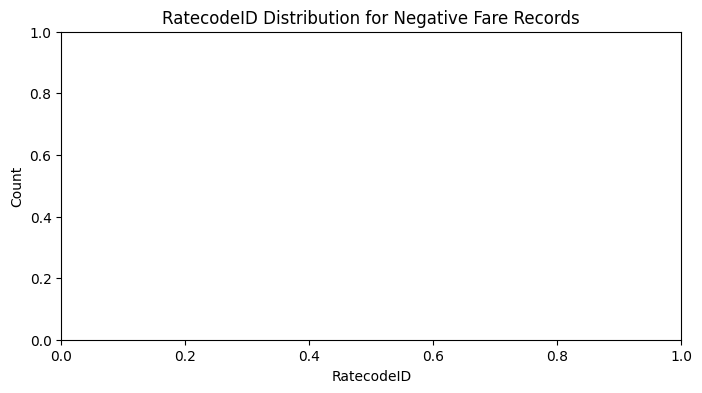

In [17]:
# Find which columns have negative values
# Analyse RatecodeID for the negative fare amounts

plt.figure(figsize=(8,4))

sns.countplot(
    data=negative_fare_df,
    x='RatecodeID'
)

plt.title('RatecodeID Distribution for Negative Fare Records')
plt.xlabel('RatecodeID')
plt.ylabel('Count')

plt.show()


In [18]:
# fix these negative values
# Find which columns have negative values

numeric_cols = df.select_dtypes(include=np.number).columns

negative_counts = {}

for col in numeric_cols:

    neg_count = (df[col] < 0).sum()

    if neg_count > 0:
        negative_counts[col] = neg_count

negative_counts



{'extra': np.int64(2),
 'mta_tax': np.int64(14),
 'improvement_surcharge': np.int64(14),
 'total_amount': np.int64(14),
 'congestion_surcharge': np.int64(10),
 'airport_fee': np.int64(3)}

### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




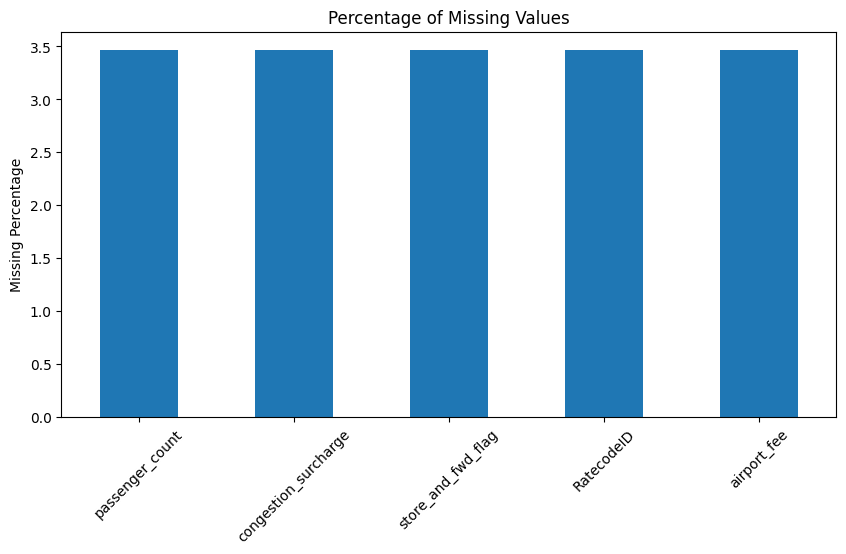

In [19]:
# Find the proportion of missing values in each column
# =========================================================
# 2.2.1 Find the proportion of missing values in each column
# =========================================================

missing_percent = (
    df.isnull()
    .mean()
    .sort_values(ascending=False) * 100
)

missing_percent

# visualising missing values percentage

missing_percent = missing_percent[missing_percent > 0]

plt.figure(figsize=(10,5))

missing_percent.plot(kind='bar')

plt.title('Percentage of Missing Values')
plt.ylabel('Missing Percentage')

plt.xticks(rotation=45)

plt.show()



**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [20]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'
# =========================================================
# 2.2.2 Display the rows with null values
# =========================================================

null_rows = df[df['passenger_count'].isnull()]

print(null_rows.shape)

null_rows.head()

# checking zero passenger counts as well

(df['passenger_count'] == 0).sum()

# replacing zeroes with NaN because zero passengers is not realistic

df.loc[df['passenger_count'] == 0, 'passenger_count'] = np.nan

# Impute NaN values in passenger_count

# median seems safer because passenger count is slightly skewed

passenger_median = df['passenger_count'].median()

df['passenger_count'].fillna(passenger_median, inplace=True)

# quick check
df['passenger_count'].isnull().sum()

(9936, 20)


np.int64(0)

Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [21]:
# Fix missing values in 'RatecodeID'

# =========================================================
# 2.2.3 Fix missing values in RatecodeID
# =========================================================

# checking missing values first

df['RatecodeID'].isnull().sum()

# checking distribution

df['RatecodeID'].value_counts(dropna=False)

# using mode because this is a categorical-like column

ratecode_mode = df['RatecodeID'].mode()[0]

df['RatecodeID'].fillna(ratecode_mode, inplace=True)

# validation
df['RatecodeID'].isnull().sum()


np.int64(0)

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [22]:
# handle null values in congestion_surcharge
# =========================================================
# 2.2.4 handle null values in congestion_surcharge
# =========================================================

df['congestion_surcharge'].isnull().sum()

# checking basic distribution

df['congestion_surcharge'].describe()

# replacing null values with median surcharge

cong_median = df['congestion_surcharge'].median()

df['congestion_surcharge'].fillna(cong_median, inplace=True)

# validation
df['congestion_surcharge'].isnull().sum()

np.int64(0)

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [23]:
# Handle any remaining missing values

# =========================================================
# checking missing values in remaining columns
# =========================================================

remaining_missing = df.isnull().sum()

remaining_missing = remaining_missing[remaining_missing > 0]

remaining_missing

# handling missing values in remaining columns

# filling categorical columns with mode
categorical_cols = [
    'store_and_fwd_flag',
    'payment_type'
]

for col in categorical_cols:

    if col in df.columns:

        mode_val = df[col].mode()[0]

        df[col].fillna(mode_val, inplace=True)

# filling numerical columns with median
numeric_fill_cols = [
    'trip_distance',
    'fare_amount',
    'tip_amount',
    'tolls_amount',
    'total_amount'
]

for col in numeric_fill_cols:

    if col in df.columns:

        median_val = df[col].median()

        df[col].fillna(median_val, inplace=True)

# final missing value check

final_missing = df.isnull().sum()

final_missing[final_missing > 0]

,0
airport_fee,9936


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

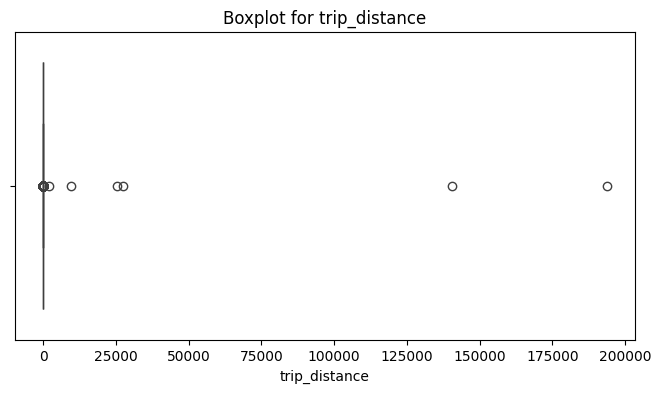

(7, 20)
(9, 20)
(6, 20)


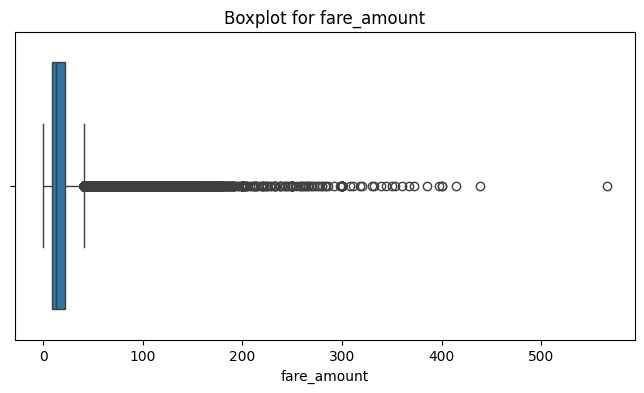

(0, 20)
(9, 20)
(0, 20)


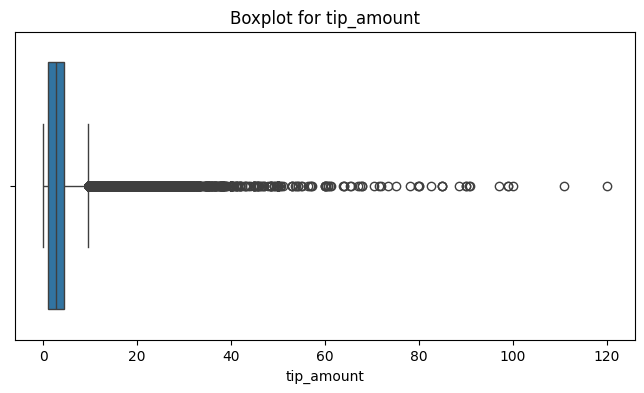

(0, 20)
(9, 20)
(0, 20)


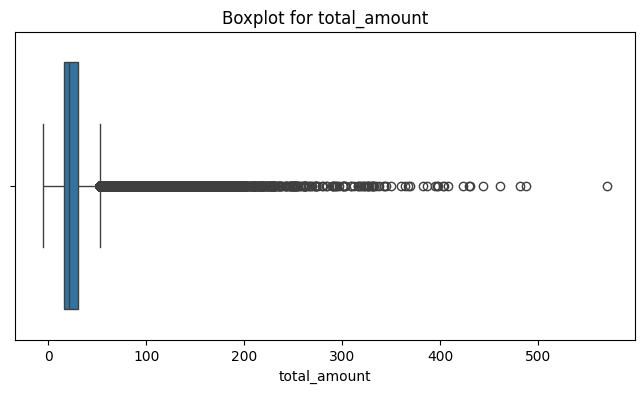

(0, 20)
(9, 20)
(0, 20)


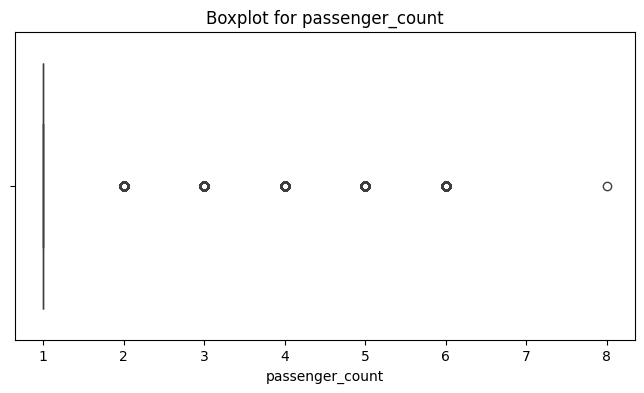

(0, 20)
(9, 20)
(0, 20)


In [24]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns

df.describe().T

# Check for potential out of place values in various columns

numeric_cols = [
    'trip_distance',
    'fare_amount',
    'tip_amount',
    'total_amount',
    'passenger_count'
]

for col in numeric_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot for {col}')

    plt.show()

    # checking unusually high fare with near zero distance

    high_fare_low_distance = df[
        (df['trip_distance'] < 0.5) &
        (df['fare_amount'] > 300)
    ]

    print(high_fare_low_distance.shape)

    high_fare_low_distance.head()

    # checking zero fare and zero distance
    # but different pickup and dropoff zones

    invalid_zero_trips = df[
        (df['trip_distance'] == 0) &
        (df['fare_amount'] == 0) &
        (df['PULocationID'] != df['DOLocationID'])
    ]

    print(invalid_zero_trips.shape)

    invalid_zero_trips.head()

    # checking extremely high trip distances

    long_distance_trips = df[df['trip_distance'] > 250]

    print(long_distance_trips.shape)

    long_distance_trips.head()

    # checking invalid payment types

    df['payment_type'].value_counts(dropna=False)

    # =========================================================
    # Fixing identified outliers
    # =========================================================

    # removing suspicious high fare but almost zero distance trips

    df = df[
        ~(
            (df['trip_distance'] < 0.5) &
            (df['fare_amount'] > 300)
        )
    ]

    # removing extremely large trip distances

    df = df[df['trip_distance'] <= 250]

    # removing payment_type = 0 since it is not defined

    df = df[df['payment_type'] != 0]



**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [25]:
# remove passenger_count > 6

df = df[df['passenger_count'] <= 6]

# quick check
df['passenger_count'].value_counts().sort_index()


,count
passenger_count,
1.0,212883
2.0,41758
3.0,10054
4.0,5857
5.0,3713
6.0,2392


In [26]:
# Continue with outlier handling
# removing negative values if still present accidentally

money_cols = [
    'fare_amount',
    'tip_amount',
    'total_amount',
    'trip_distance'
]

for col in money_cols:

    df = df[df[col] >= 0]



In [27]:
# Do any columns need standardising?

# converting column names to lowercase for consistency

df.columns = [col.lower() for col in df.columns]

# quick look at columns
df.columns.tolist()

# checking final shape after cleaning

print(df.shape)



(276643, 20)


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [28]:
df.columns.tolist()

['vendorid',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'ratecodeid',
 'store_and_fwd_flag',
 'pulocationid',
 'dolocationid',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'trip_month']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

Categorical Variables
['vendorid', 'ratecodeid', 'pulocationid', 'dolocationid', 'payment_type']

Numerical Variables
['passenger_count', 'trip_distance', 'pickup_hour', 'trip_duration']

Datetime Variables
['tpep_pickup_datetime', 'tpep_dropoff_datetime']

Monetary Variables (Numerical)
['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']
All monetary columns are numerical because they represent continuous fare related values.


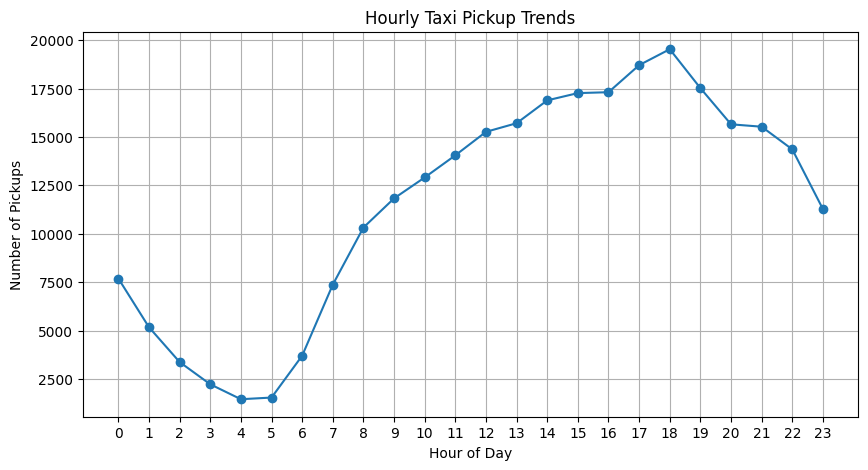

In [30]:
# =========================================================
# 3.1 General EDA: Finding Patterns and Trends
# 3.1.1 Classify variables into categorical and numerical
# =========================================================
# creating some useful datetime related columns first

df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# pickup hour
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

# trip duration in minutes
df['trip_duration'] = (
    (
        df['tpep_dropoff_datetime'] -
        df['tpep_pickup_datetime']
    )
    .dt.total_seconds() / 60
)
# categorising variables

categorical_vars = [
    'vendorid',
    'ratecodeid',
    'pulocationid',
    'dolocationid',
    'payment_type'
]

numerical_vars = [
    'passenger_count',
    'trip_distance',
    'pickup_hour',
    'trip_duration'
]

datetime_vars = [
    'tpep_pickup_datetime',
    'tpep_dropoff_datetime'
]

money_vars = [
    'fare_amount',
    'extra',
    'mta_tax',
    'tip_amount',
    'tolls_amount',
    'improvement_surcharge',
    'total_amount',
    'congestion_surcharge',
    'airport_fee'
]
# displaying grouped variable types

print('Categorical Variables')
print(categorical_vars)

print('\nNumerical Variables')
print(numerical_vars)

print('\nDatetime Variables')
print(datetime_vars)

print('\nMonetary Variables (Numerical)')
print(money_vars)
# small summary note

print('All monetary columns are numerical because they represent continuous fare related values.')

# Find and show the hourly trends in taxi pickups

# extracting useful datetime features

df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()

df['pickup_month'] = df['tpep_pickup_datetime'].dt.month_name()

# =========================================================
# Find and show the hourly trends in taxi pickups
# =========================================================

hourly_pickups = (
    df.groupby('pickup_hour')
    .size()
)

hourly_pickups

# plotting hourly pickups

plt.figure(figsize=(10,5))

hourly_pickups.plot(marker='o')

plt.title('Hourly Taxi Pickup Trends')

plt.xlabel('Hour of Day')

plt.ylabel('Number of Pickups')

plt.xticks(range(0,24))

plt.grid(True)

plt.show()



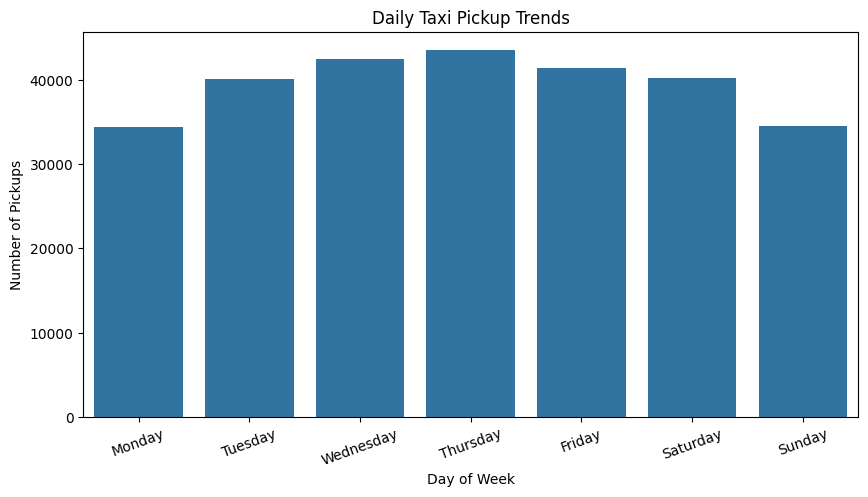

In [31]:
# Find and show the daily trends in taxi pickups (days of the week)

# =========================================================
# Find and show the daily trends in taxi pickups
# =========================================================

day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

daily_pickups = (
    df['pickup_day']
    .value_counts()
    .reindex(day_order)
)

daily_pickups

# plotting daily pickup trends

plt.figure(figsize=(10,5))

sns.barplot(
    x=daily_pickups.index,
    y=daily_pickups.values
)

plt.title('Daily Taxi Pickup Trends')

plt.xlabel('Day of Week')

plt.ylabel('Number of Pickups')

plt.xticks(rotation=20)

plt.show()



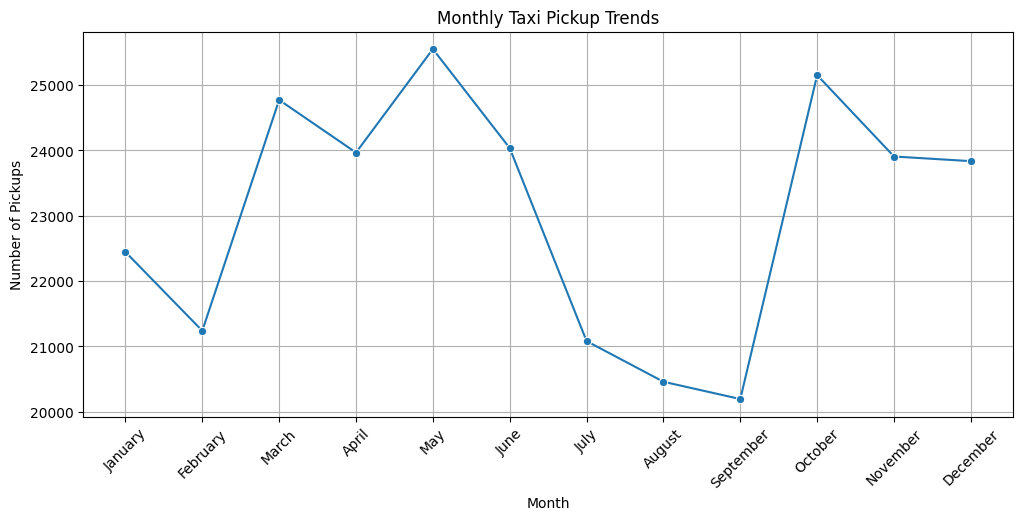

In [32]:
# Show the monthly trends in pickups


month_order = [
    'January', 'February', 'March',
    'April', 'May', 'June',
    'July', 'August', 'September',
    'October', 'November', 'December'
]

monthly_pickups = (
    df['pickup_month']
    .value_counts()
    .reindex(month_order)
)

monthly_pickups

# plotting monthly pickup trends

plt.figure(figsize=(12,5))

sns.lineplot(
    x=monthly_pickups.index,
    y=monthly_pickups.values,
    marker='o'
)

plt.title('Monthly Taxi Pickup Trends')

plt.xlabel('Month')

plt.ylabel('Number of Pickups')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()


##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?


Column : fare_amount
Zero values : 86
Negative values : 0

Column : tip_amount
Zero values : 61554
Negative values : 0

Column : total_amount
Zero values : 39
Negative values : 0

Column : trip_distance
Zero values : 3324
Negative values : 0


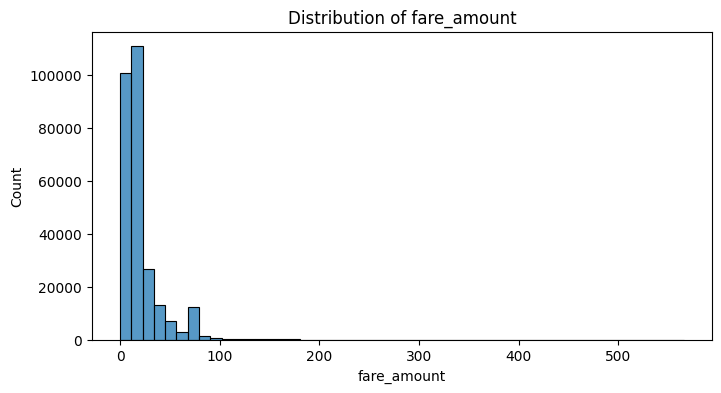

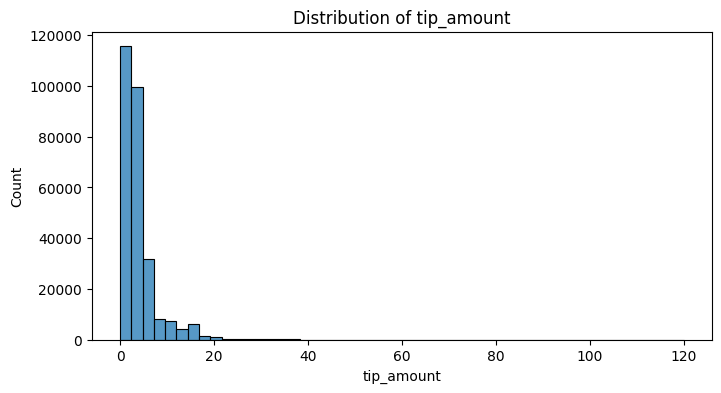

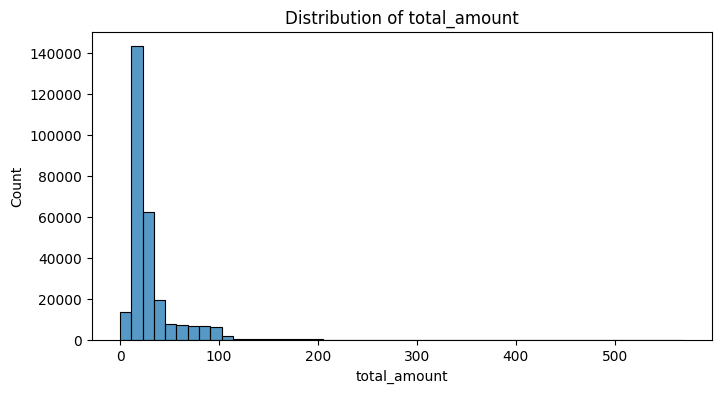

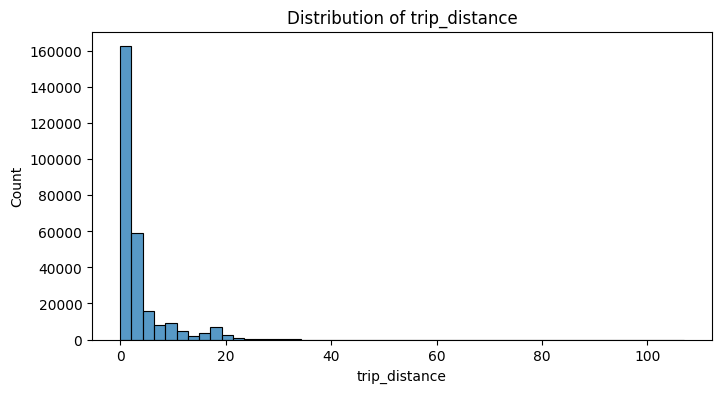

(273272, 24)
original dataset shape : (276643, 24)
financial analysis dataset shape : (273272, 24)


In [33]:
# Analyse the above parameters
# =========================================================
# Financial Analysis
# Analyse fare_amount, tip_amount, total_amount and trip_distance
# =========================================================


financial_cols = [
    'fare_amount',
    'tip_amount',
    'total_amount',
    'trip_distance'
]

# checking zero and negative values

for col in financial_cols:

    zero_count = (df[col] == 0).sum()
    negative_count = (df[col] < 0).sum()

    print(f'\nColumn : {col}')
    print(f'Zero values : {zero_count}')
    print(f'Negative values : {negative_count}')

# visualising distributions

for col in financial_cols:

    plt.figure(figsize=(8,4))

    sns.histplot(df[col], bins=50)

    plt.title(f'Distribution of {col}')

    plt.show()

# checking some rows with zero values

df[
    (df['fare_amount'] == 0) |
    (df['trip_distance'] == 0)
][financial_cols].head()


# Note:
# It may be useful to create a separate dataframe excluding
# zero fare and zero distance trips for cleaner financial analysis

financial_df = df[
    (df['fare_amount'] > 0) &
    (df['trip_distance'] > 0) &
    (df['total_amount'] > 0)
].copy()

print(financial_df.shape)


# quick comparison

print('original dataset shape :', df.shape)

print('financial analysis dataset shape :', financial_df.shape)


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [34]:
# Create a df with non zero entries for the selected parameters.

# =========================================================
# 3.1.3 Filter out zero values from financial columns
# =========================================================

# checking trips where pickup and dropoff zones are same
# and trip distance is zero

same_zone_zero_distance = df[
    (df['trip_distance'] == 0) &
    (df['pulocationid'] == df['dolocationid'])
]

print(same_zone_zero_distance.shape)

# Note:
# Some zero distance trips may still be valid if pickup and
# dropoff happen within the same taxi zone.
# Hence, we will mainly filter out financial zero values
# for cleaner fare analysis.

# Create a dataframe with non-zero entries
# for important financial parameters

financial_df = df[
    (df['fare_amount'] > 0) &
    (df['total_amount'] > 0) &
    (df['trip_distance'] > 0)
].copy()

print(financial_df.shape)

# quick validation

for col in ['fare_amount', 'total_amount', 'trip_distance']:

    print(col)
    print('zero values :', (financial_df[col] == 0).sum())
    print()

# preview cleaned financial dataframe

financial_df.head()



(2161, 24)
(273272, 24)
fare_amount
zero values : 0

total_amount
zero values : 0

trip_distance
zero values : 0



,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,store_and_fwd_flag,pulocationid,dolocationid,payment_type,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,trip_month,pickup_hour,trip_duration,pickup_day,pickup_month
0,2,2023-01-10 00:44:09,2023-01-10 00:51:23,1.0,1.97,1.0,N,142,164,1,...,0.0,1.0,18.84,2.5,0.00,1,0,7.233333,Tuesday,January
1,1,2023-01-15 00:32:10,2023-01-15 00:42:27,1.0,1.50,1.0,N,113,79,1,...,0.0,1.0,17.00,2.5,0.00,1,0,10.283333,Sunday,January
2,1,2023-01-29 00:29:35,2023-01-29 00:42:50,2.0,2.60,1.0,N,263,143,1,...,0.0,1.0,24.70,2.5,0.00,1,0,13.250000,Sunday,January
3,2,2023-01-14 00:14:30,2023-01-14 00:27:04,1.0,1.79,1.0,N,79,158,1,...,0.0,1.0,19.98,2.5,0.00,1,0,12.566667,Saturday,January
4,2,2023-01-03 00:55:05,2023-01-03 01:03:28,1.0,3.34,1.0,N,132,132,2,...,0.0,1.0,19.35,0.0,1.25,1,0,8.383333,Tuesday,January


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

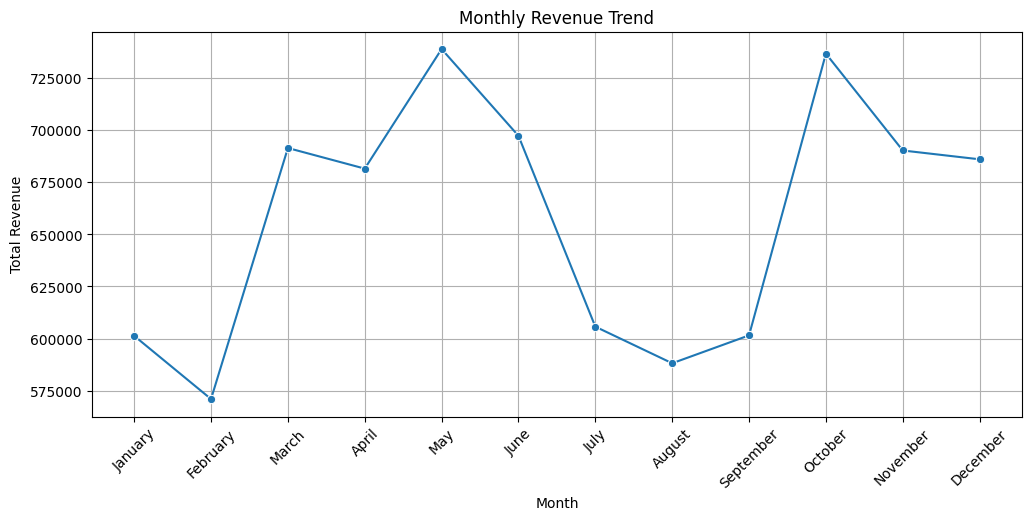

Highest Revenue Month : May
Lowest Revenue Month : February


In [35]:
# Group data by month and analyse monthly revenue

# =========================================================
# 3.1.4 Analyse the monthly revenue (total_amount) trend
# =========================================================

monthly_revenue = (
    financial_df
    .groupby('pickup_month')['total_amount']
    .sum()
)

# arranging months in proper calendar order

month_order = [
    'January', 'February', 'March',
    'April', 'May', 'June',
    'July', 'August', 'September',
    'October', 'November', 'December'
]

monthly_revenue = monthly_revenue.reindex(month_order)

monthly_revenue

# plotting monthly revenue trend

plt.figure(figsize=(12,5))

sns.lineplot(
    x=monthly_revenue.index,
    y=monthly_revenue.values,
    marker='o'
)

plt.title('Monthly Revenue Trend')

plt.xlabel('Month')

plt.ylabel('Total Revenue')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

# quick summary statistics

print('Highest Revenue Month :',
      monthly_revenue.idxmax())

print('Lowest Revenue Month :',
      monthly_revenue.idxmin())

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

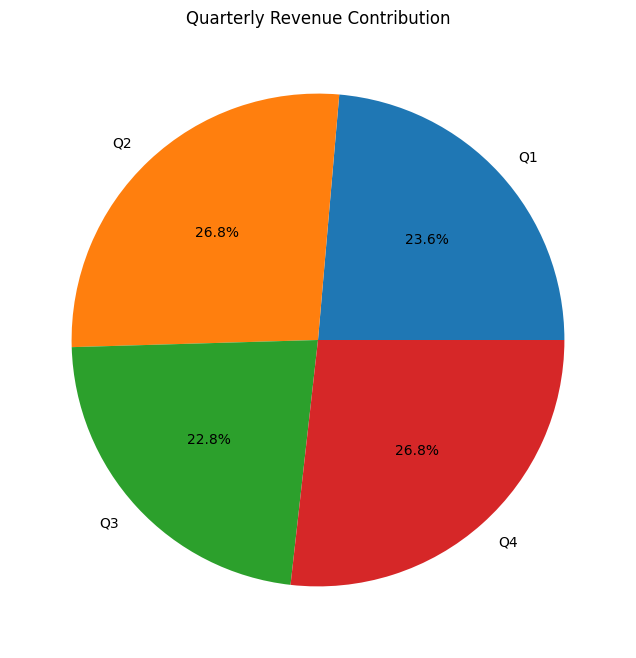

Highest revenue contribution quarter : 2
Lowest revenue contribution quarter : 3


In [36]:
# Calculate proportion of each quarter
# =========================================================
# 3.1.5 Show the proportion of each quarter in yearly revenue
# =========================================================
# creating quarter column

financial_df['pickup_quarter'] = (
    financial_df['tpep_pickup_datetime']
    .dt.quarter
)
# Calculate proportion of each quarter

quarter_revenue = (
    financial_df
    .groupby('pickup_quarter')['total_amount']
    .sum()
)

quarter_revenue
# calculating revenue proportion percentage

quarter_revenue_percent = (
    quarter_revenue /
    quarter_revenue.sum()
) * 100

quarter_revenue_percent

# plotting quarterly revenue share

plt.figure(figsize=(8,8))

plt.pie(
    quarter_revenue_percent.values,
    labels=[
        'Q1',
        'Q2',
        'Q3',
        'Q4'
    ],
    autopct='%.1f%%'
)

plt.title('Quarterly Revenue Contribution')

plt.show()

# quick summary

print('Highest revenue contribution quarter :',
      quarter_revenue_percent.idxmax())

print('Lowest revenue contribution quarter :',
      quarter_revenue_percent.idxmin())



**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

(273272, 25)
Correlation between trip distance and fare amount :
0.9463


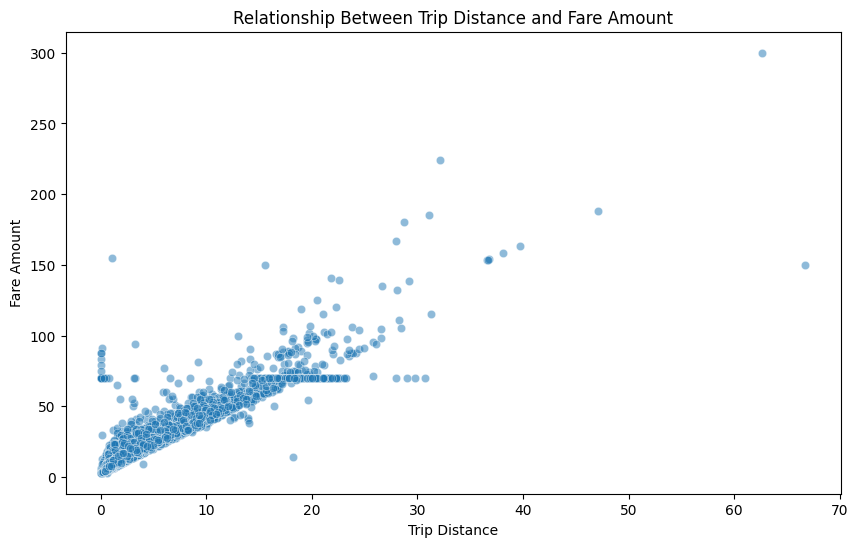

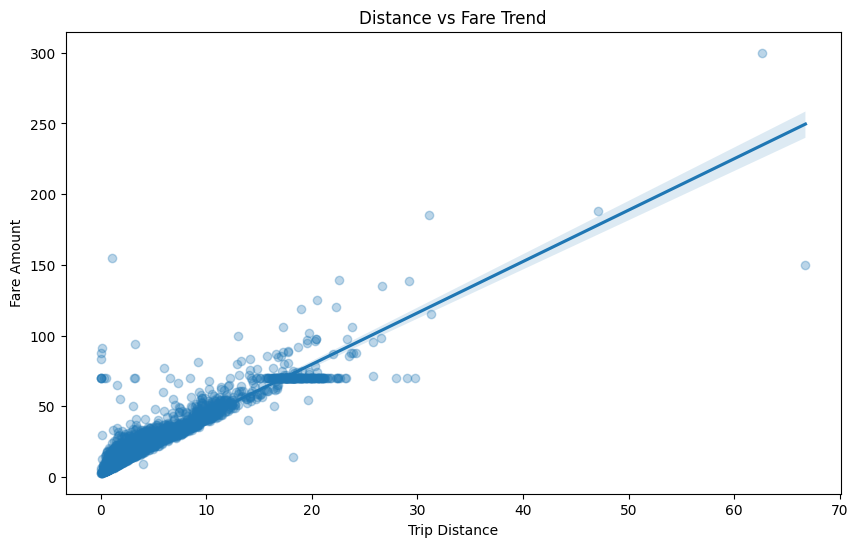

Fare amount generally increases with trip distance.


In [37]:
# Show how trip fare is affected by distance
# =========================================================
# 3.1.6 Relationship between trip_distance and fare_amount
# =========================================================
# removing zero distance trips for cleaner analysis

distance_fare_df = financial_df[
    financial_df['trip_distance'] > 0
].copy()

print(distance_fare_df.shape)

# checking correlation between distance and fare

distance_fare_corr = (
    distance_fare_df['trip_distance']
    .corr(distance_fare_df['fare_amount'])
)

print('Correlation between trip distance and fare amount :')

print(round(distance_fare_corr, 4))

# Show how trip fare is affected by distance

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=distance_fare_df.sample(10000, random_state=42),
    x='trip_distance',
    y='fare_amount',
    alpha=0.5
)

plt.title('Relationship Between Trip Distance and Fare Amount')

plt.xlabel('Trip Distance')

plt.ylabel('Fare Amount')

plt.show()

# adding regression line for trend

plt.figure(figsize=(10,6))

sns.regplot(
    data=distance_fare_df.sample(5000, random_state=42),
    x='trip_distance',
    y='fare_amount',
    scatter_kws={'alpha':0.3}
)

plt.title('Distance vs Fare Trend')

plt.xlabel('Trip Distance')

plt.ylabel('Fare Amount')

plt.show()

# small interpretation

if distance_fare_corr > 0:
    print('Fare amount generally increases with trip distance.')
else:
    print('Weak or inverse relationship observed.')


**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

Correlation between fare amount and trip duration :
0.2644


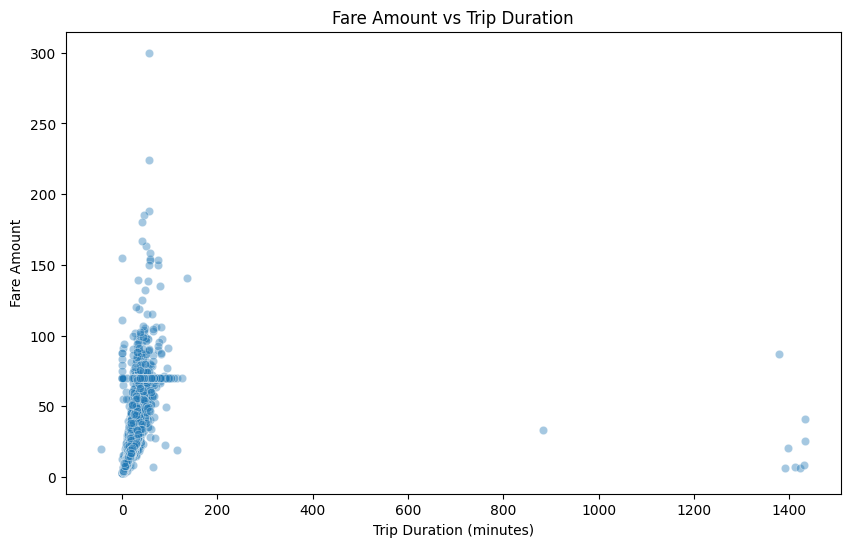

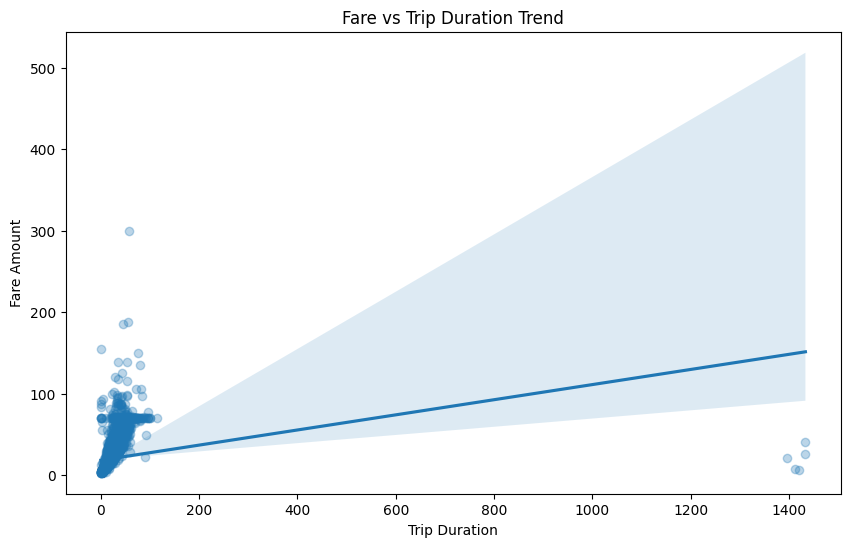

In [38]:
# Show relationship between fare and trip duration
# =========================================================
# 3.1.7 Correlation Analysis
# =========================================================

# correlation between fare amount and trip duration

fare_duration_corr = (
    financial_df['fare_amount']
    .corr(financial_df['trip_duration'])
)

print('Correlation between fare amount and trip duration :')

print(round(fare_duration_corr, 4))

# Show relationship between fare and trip duration

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=financial_df.sample(10000, random_state=42),
    x='trip_duration',
    y='fare_amount',
    alpha=0.4
)

plt.title('Fare Amount vs Trip Duration')

plt.xlabel('Trip Duration (minutes)')

plt.ylabel('Fare Amount')

plt.show()

# regression trend for fare and duration

plt.figure(figsize=(10,6))

sns.regplot(
    data=financial_df.sample(5000, random_state=42),
    x='trip_duration',
    y='fare_amount',
    scatter_kws={'alpha':0.3}
)

plt.title('Fare vs Trip Duration Trend')

plt.xlabel('Trip Duration')

plt.ylabel('Fare Amount')

plt.show()



Correlation between fare amount and passenger count :
0.0444


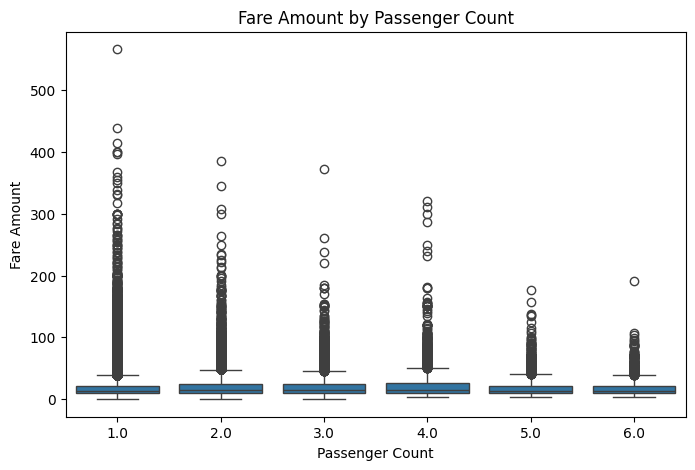

In [39]:
# Show relationship between fare and number of passengers
# correlation between fare amount and passenger count

fare_passenger_corr = (
    financial_df['fare_amount']
    .corr(financial_df['passenger_count'])
)

print('Correlation between fare amount and passenger count :')

print(round(fare_passenger_corr, 4))

# Show relationship between fare and number of passengers

plt.figure(figsize=(8,5))

sns.boxplot(
    data=financial_df,
    x='passenger_count',
    y='fare_amount'
)

plt.title('Fare Amount by Passenger Count')

plt.xlabel('Passenger Count')

plt.ylabel('Fare Amount')

plt.show()


Correlation between tip amount and trip distance :
0.5957


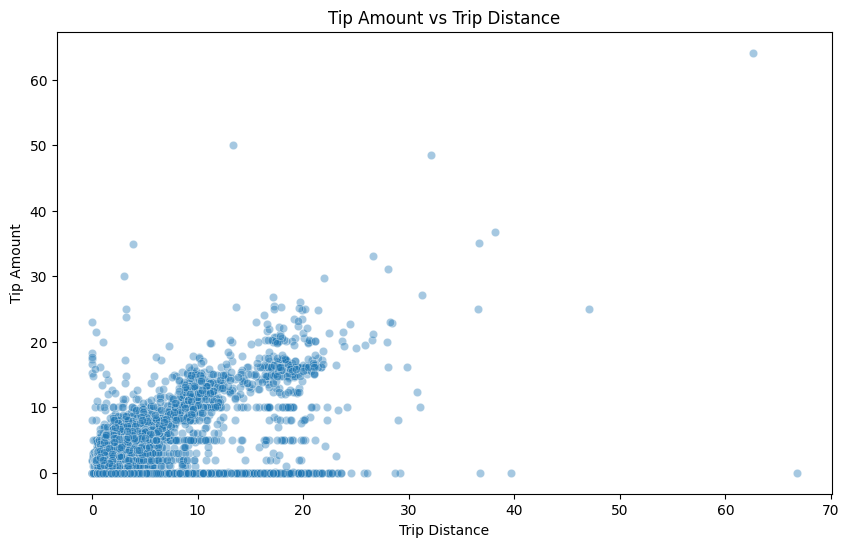

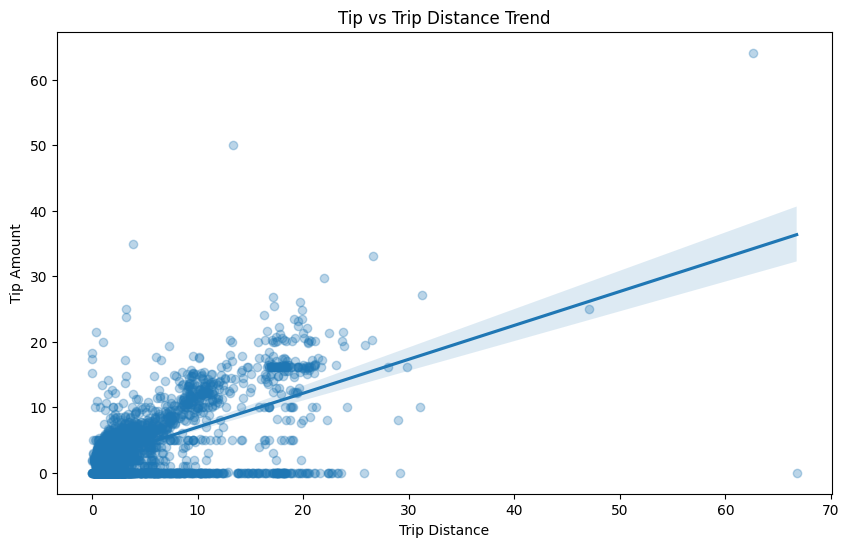

In [40]:
# Show relationship between tip and trip distance
# correlation between tip amount and trip distance

tip_distance_corr = (
    financial_df['tip_amount']
    .corr(financial_df['trip_distance'])
)

print('Correlation between tip amount and trip distance :')

print(round(tip_distance_corr, 4))

# Show relationship between tip and trip distance

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=financial_df.sample(10000, random_state=42),
    x='trip_distance',
    y='tip_amount',
    alpha=0.4
)

plt.title('Tip Amount vs Trip Distance')

plt.xlabel('Trip Distance')

plt.ylabel('Tip Amount')

plt.show()

# regression trend for tip and distance

plt.figure(figsize=(10,6))

sns.regplot(
    data=financial_df.sample(5000, random_state=42),
    x='trip_distance',
    y='tip_amount',
    scatter_kws={'alpha':0.3}
)

plt.title('Tip vs Trip Distance Trend')

plt.xlabel('Trip Distance')

plt.ylabel('Tip Amount')

plt.show()



**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

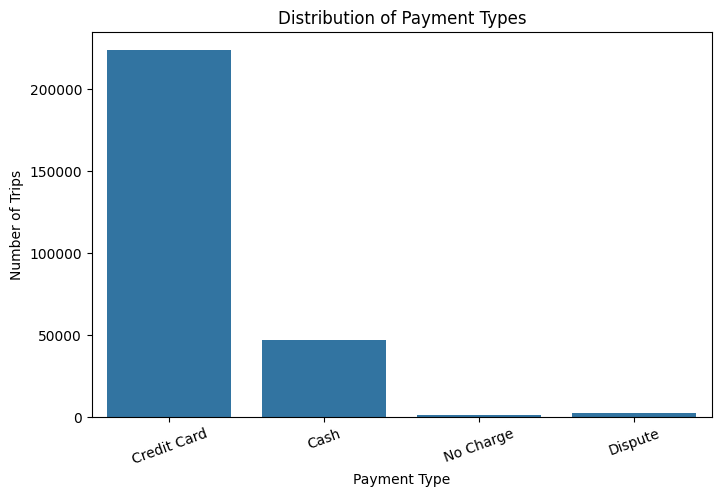

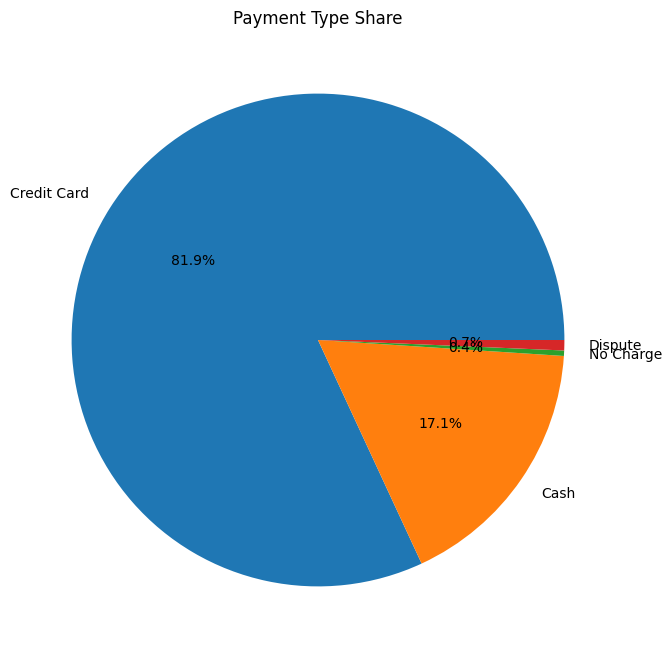

Most commonly used payment type :
Credit Card


In [41]:
# Analyse the distribution of different payment types (payment_type).
# =========================================================
# 3.1.8 Analyse the distribution of payment types
# =========================================================
# checking payment type distribution

payment_distribution = (
    financial_df['payment_type']
    .value_counts()
    .sort_index()
)

payment_distribution

# mapping payment type codes using data dictionary

payment_map = {
    1: 'Credit Card',
    2: 'Cash',
    3: 'No Charge',
    4: 'Dispute',
    5: 'Unknown',
    6: 'Voided Trip'
}

payment_distribution.index = (
    payment_distribution.index
    .map(payment_map)
)

payment_distribution

# plotting payment type distribution

plt.figure(figsize=(8,5))

sns.barplot(
    x=payment_distribution.index,
    y=payment_distribution.values
)

plt.title('Distribution of Payment Types')

plt.xlabel('Payment Type')

plt.ylabel('Number of Trips')

plt.xticks(rotation=20)

plt.show()

# percentage contribution of payment types

payment_percent = (
    payment_distribution /
    payment_distribution.sum()
) * 100

round(payment_percent, 2)

# pie chart for payment distribution

plt.figure(figsize=(8,8))

plt.pie(
    payment_percent.values,
    labels=payment_percent.index,
    autopct='%.1f%%'
)

plt.title('Payment Type Share')

plt.show()

# most common payment method

print('Most commonly used payment type :')

print(payment_distribution.idxmax())



- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [42]:
!pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [43]:
import geopandas as gpd


# Read the shapefile using geopandas
file_name = 'taxi_zones.shp'
folder_path = '/content/drive/MyDrive/Assignments/EDA/taxi_zones'
file_path = os.path.join(folder_path, file_name)
zones = gpd.read_file(file_path)
print(zones.shape)
zones.head()

(263, 7)


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


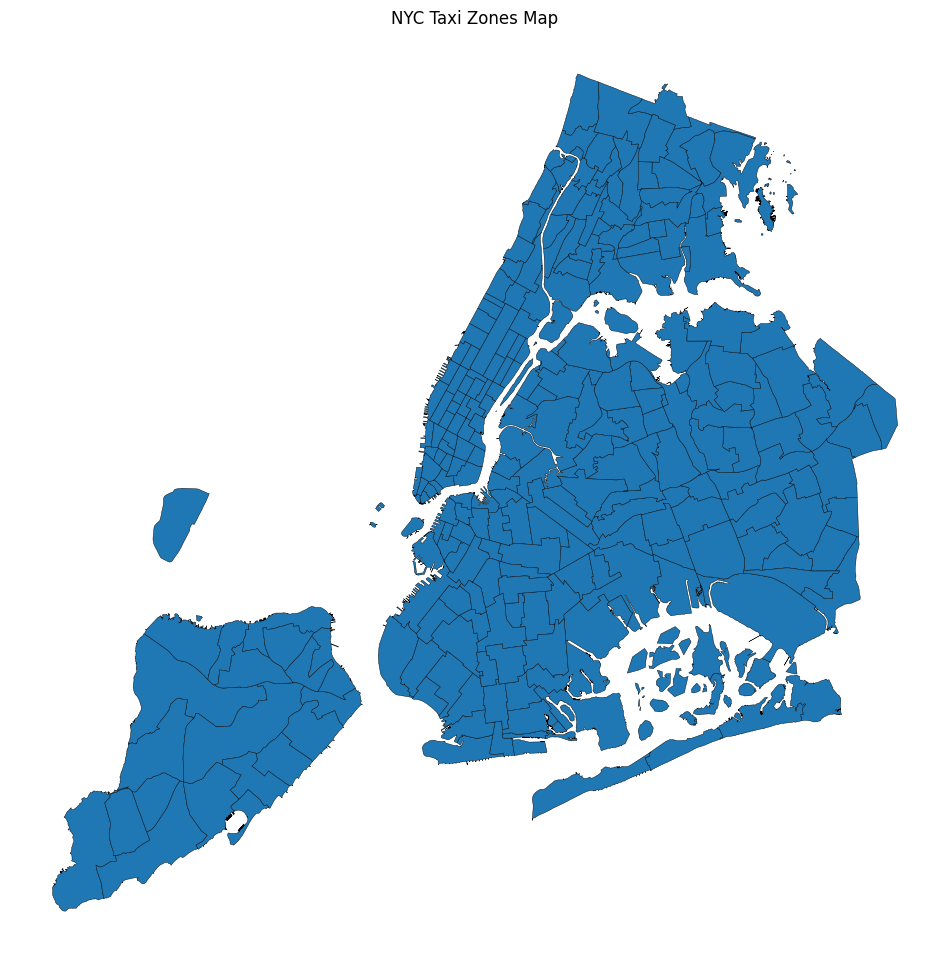

In [44]:
# print(zones.info())
# zones.plot()

# checking information about the zones geodataframe

print(zones.info())

# plotting all taxi zones

zones.plot(
    figsize=(12,12),
    edgecolor='black',
    linewidth=0.3
)

plt.title('NYC Taxi Zones Map')

plt.axis('off')

plt.show()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [45]:
# Merge zones and trip records using locationID and PULocationID
# =========================================================
# 3.1.10 Merge zones data with trip records
# using LocationID and PULocationID
# =========================================================
# checking required columns before merge

print(zones.columns)

print(df.columns)

# selecting only required zone columns for merge

zones_subset = zones[
    [
        'LocationID',
        'zone',
        'borough',
        'geometry'
    ]
].copy()

# Merge zones and trip records using
# LocationID and PULocationID

pickup_zones_df = pd.merge(
    df,
    zones_subset,

    left_on='pulocationid',
    right_on='LocationID',

    how='left'
)

# renaming columns for better clarity

pickup_zones_df.rename(
    columns={
        'zone':'pickup_zone',
        'borough':'pickup_borough'
    },
    inplace=True
)

# checking merged dataframe

print(pickup_zones_df.shape)

pickup_zones_df.head()

# checking missing zone mappings if any

print(
    'missing pickup zones :',

    pickup_zones_df['pickup_zone'].isnull().sum()
)

# quick preview of merged columns

pickup_zones_df[
    [
        'pulocationid',
        'pickup_zone',
        'pickup_borough'
    ]
].head()



Index(['OBJECTID', 'Shape_Leng', 'Shape_Area', 'zone', 'LocationID', 'borough',
       'geometry'],
      dtype='object')
Index(['vendorid', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'ratecodeid', 'store_and_fwd_flag',
       'pulocationid', 'dolocationid', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee', 'trip_month',
       'pickup_hour', 'trip_duration', 'pickup_day', 'pickup_month'],
      dtype='object')
(276661, 28)
missing pickup zones : 2803


,pulocationid,pickup_zone,pickup_borough
0,142,Lincoln Square East,Manhattan
1,113,Greenwich Village North,Manhattan
2,263,Yorkville West,Manhattan
3,79,East Village,Manhattan
4,132,JFK Airport,Queens


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

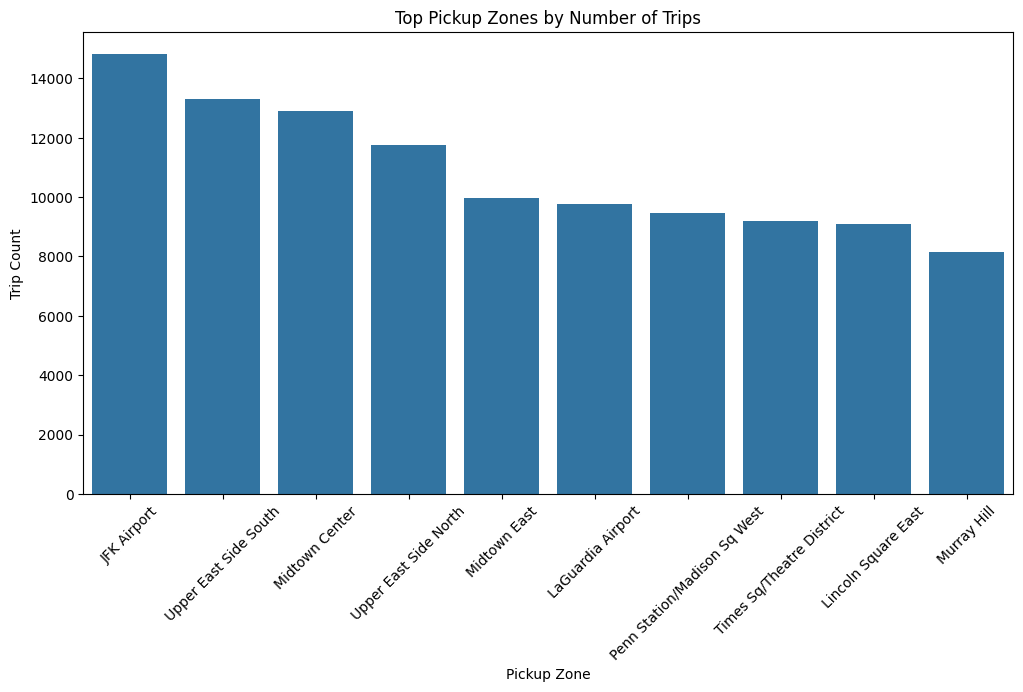

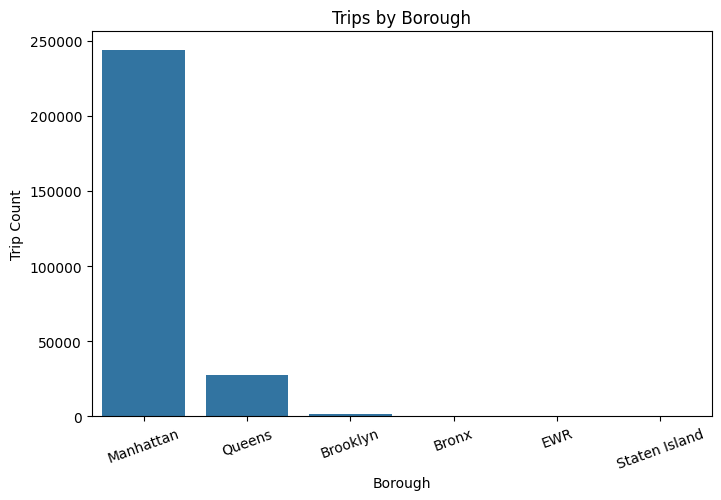

In [46]:
# Group data by location and calculate the number of trips
# =========================================================
# 3.1.11 Analyse trips by pickup location
# =========================================================

location_trip_counts = (
    pickup_zones_df
    .groupby(
        [
            'pulocationid',
            'pickup_zone',
            'pickup_borough'
        ]
    )
    .size()
    .reset_index(name='trip_count')
)
# sorting locations by trip count

location_trip_counts = (
    location_trip_counts
    .sort_values(
        by='trip_count',
        ascending=False
    )
)

location_trip_counts.head(10)
# top pickup locations

top_locations = location_trip_counts.head(10)

top_locations

# visualising top pickup zones

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_locations,
    x='pickup_zone',
    y='trip_count'
)

plt.title('Top Pickup Zones by Number of Trips')

plt.xlabel('Pickup Zone')

plt.ylabel('Trip Count')

plt.xticks(rotation=45)

plt.show()

# borough level pickup distribution

borough_trips = (
    pickup_zones_df['pickup_borough']
    .value_counts()
)

borough_trips

# plotting borough wise trip distribution

plt.figure(figsize=(8,5))

sns.barplot(
    x=borough_trips.index,
    y=borough_trips.values
)

plt.title('Trips by Borough')

plt.xlabel('Borough')

plt.ylabel('Trip Count')

plt.xticks(rotation=20)

plt.show()

**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [47]:
# =========================================================
# 3.1.12 Add trip counts back to GeoDataFrame
# =========================================================

# checking grouped trip count dataframe

location_trip_counts.head()

# selecting only required columns

trip_count_subset = location_trip_counts[
    [
        'pulocationid',
        'trip_count'
    ]
].copy()

# Merge trip counts back to the zones GeoDataFrame

zones_trips = zones.merge(
    trip_count_subset,

    left_on='LocationID',
    right_on='pulocationid',

    how='left'
)

# filling missing trip counts with 0

zones_trips['trip_count'] = (
    zones_trips['trip_count']
    .fillna(0)
)

# checking merged geodataframe

print(zones_trips.shape)

zones_trips.head()

# checking if any null values remain

zones_trips['trip_count'].isnull().sum()

# previewing important columns

zones_trips[
    [
        'LocationID',
        'zone',
        'borough',
        'trip_count'
    ]
].head()


(263, 9)


,LocationID,zone,borough,trip_count
0,1,Newark Airport,EWR,28.0
1,2,Jamaica Bay,Queens,0.0
2,3,Allerton/Pelham Gardens,Bronx,4.0
3,4,Alphabet City,Manhattan,269.0
4,5,Arden Heights,Staten Island,2.0


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

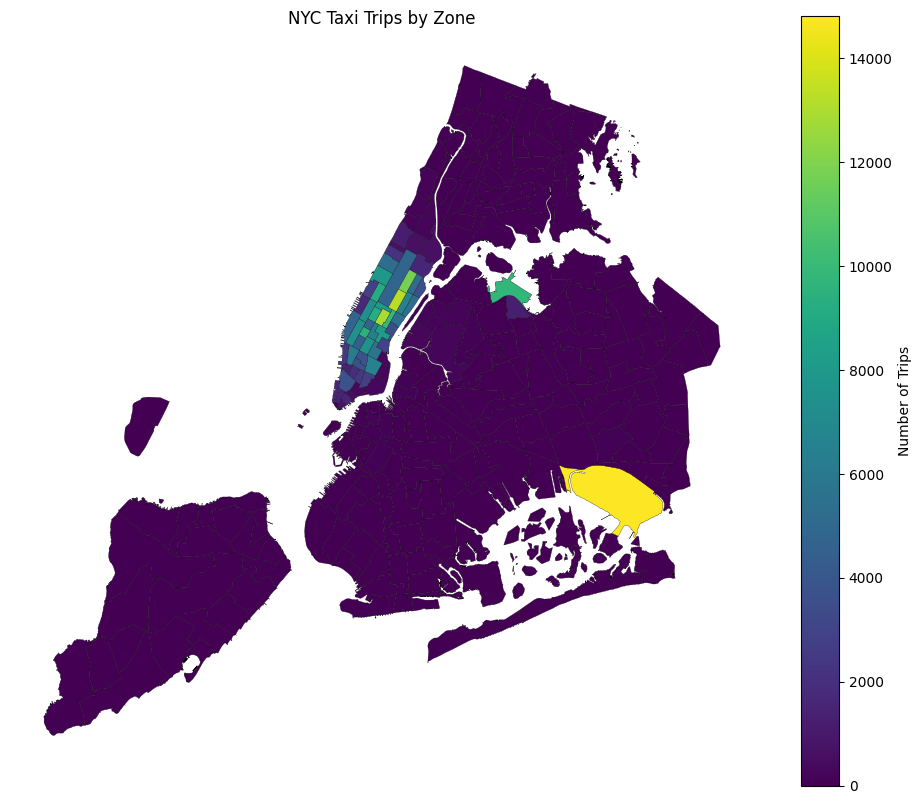

In [48]:
# =========================================================
# 3.1.13 Plot choropleth map for trip counts
# =========================================================

# Define figure and axis

fig, ax = plt.subplots(
    1,
    1,
    figsize=(12,10)
)

# Plot the map and display it

zones_trips.plot(

    column='trip_count',

    ax=ax,

    legend=True,

    legend_kwds={
        'label':'Number of Trips',
        'orientation':'vertical'
    },

    edgecolor='black',

    linewidth=0.2
)

# chart formatting

plt.title('NYC Taxi Trips by Zone')

plt.axis('off')

plt.show()





In [49]:
# can you try displaying the zones DF
# sorted by the number of trips?

zones_sorted = (
    zones_trips[
        [
            'LocationID',
            'zone',
            'borough',
            'trip_count'
        ]
    ]
    .sort_values(
        by='trip_count',
        ascending=False
    )
)

zones_sorted.head(15)



,LocationID,zone,borough,trip_count
131,132,JFK Airport,Queens,14823.0
236,237,Upper East Side South,Manhattan,13307.0
160,161,Midtown Center,Manhattan,12898.0
235,236,Upper East Side North,Manhattan,11750.0
161,162,Midtown East,Manhattan,9956.0
137,138,LaGuardia Airport,Queens,9755.0
185,186,Penn Station/Madison Sq West,Manhattan,9477.0
229,230,Times Sq/Theatre District,Manhattan,9197.0
141,142,Lincoln Square East,Manhattan,9106.0
169,170,Murray Hill,Manhattan,8152.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

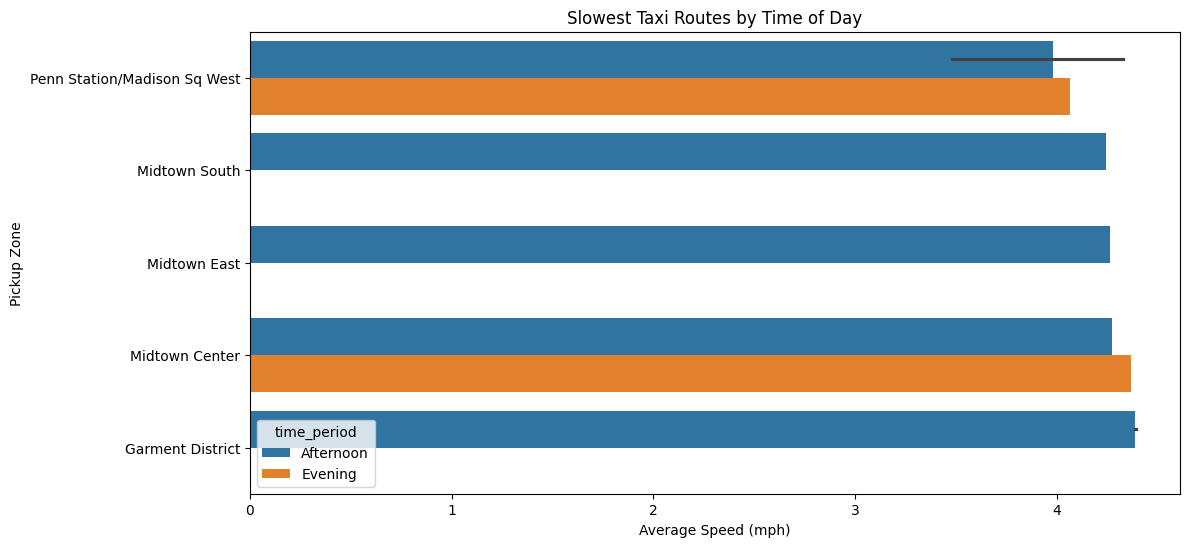

In [50]:
# =========================================================
# 3.2.1 Find routes with the slowest speeds
# at different times of the day
# =========================================================

# creating a copy for route analysis

route_df = pickup_zones_df.copy()

# calculating trip speed in miles per hour

route_df['trip_speed_mph'] = (

    route_df['trip_distance'] /

    (route_df['trip_duration'] / 60)
)
# removing invalid or extreme speeds

route_df = route_df[
    (route_df['trip_speed_mph'] > 0) &
    (route_df['trip_speed_mph'] < 80)
]
# categorising hours into time periods

def get_time_period(hour):

    if 5 <= hour < 12:
        return 'Morning'

    elif 12 <= hour < 17:
        return 'Afternoon'

    elif 17 <= hour < 21:
        return 'Evening'

    else:
        return 'Night'

route_df['time_period'] = (
    route_df['pickup_hour']
    .apply(get_time_period)
)

# grouping by route and time period

slow_routes = (

    route_df.groupby(
        [
            'pickup_zone',
            'dolocationid',
            'time_period'
        ]
    )

    .agg({
        'trip_speed_mph':'mean',
        'trip_distance':'count'
    })

    .reset_index()
)

# renaming columns

slow_routes.rename(
    columns={
        'trip_distance':'trip_count'
    },
    inplace=True
)

# considering only frequently used routes

slow_routes = slow_routes[
    slow_routes['trip_count'] >= 30
]

# finding slowest routes

slowest_routes = (

    slow_routes.sort_values(
        by='trip_speed_mph'
    )
)

slowest_routes.head(15)

# visualising slowest routes

top_slowest = slowest_routes.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_slowest,

    x='trip_speed_mph',

    y='pickup_zone',

    hue='time_period'
)

plt.title('Slowest Taxi Routes by Time of Day')

plt.xlabel('Average Speed (mph)')

plt.ylabel('Pickup Zone')

plt.show()




How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

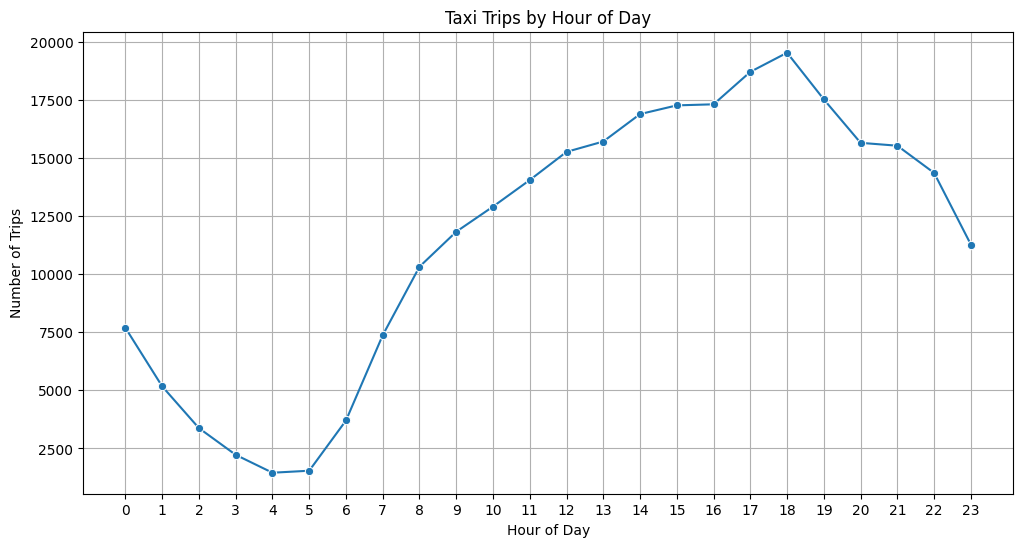

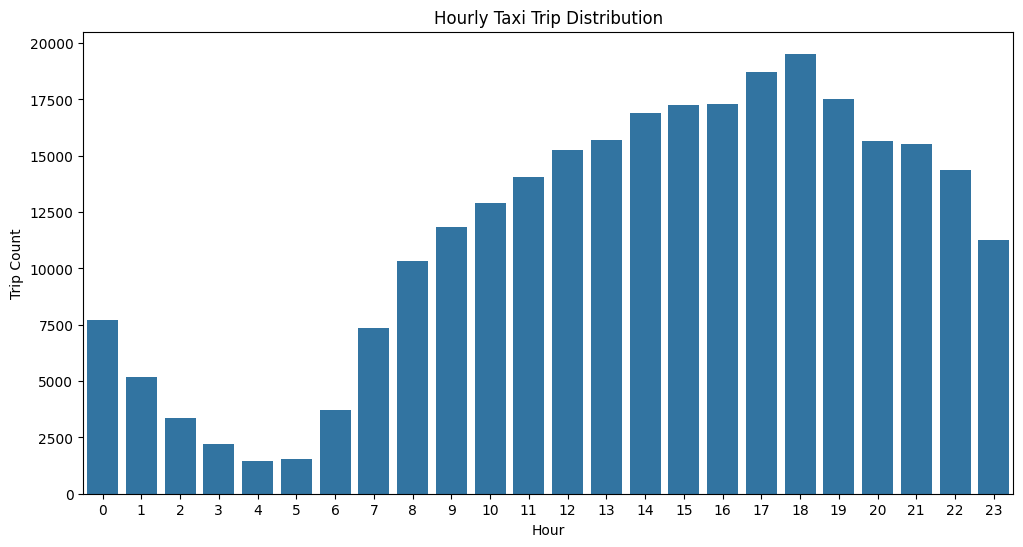

Busiest Hour : 18
Number of Trips : 19530


,count
pickup_hour,
18,19530
17,18707
19,17521
16,17310
15,17264


In [51]:
# =========================================================
# 3.2.2 Analyse trips by hour of the day
# =========================================================
# Calculate the number of trips at each hour

hourly_trip_counts = (
    df['pickup_hour']
    .value_counts()
    .sort_index()
)

hourly_trip_counts

# Visualise the number of trips per hour

plt.figure(figsize=(12,6))

sns.lineplot(
    x=hourly_trip_counts.index,
    y=hourly_trip_counts.values,
    marker='o'
)

plt.title('Taxi Trips by Hour of Day')

plt.xlabel('Hour of Day')

plt.ylabel('Number of Trips')

plt.xticks(range(0,24))

plt.grid(True)

plt.show()

# bar chart version

plt.figure(figsize=(12,6))

sns.barplot(
    x=hourly_trip_counts.index,
    y=hourly_trip_counts.values
)

plt.title('Hourly Taxi Trip Distribution')

plt.xlabel('Hour')

plt.ylabel('Trip Count')

plt.show()

# Find the busiest hour

busiest_hour = hourly_trip_counts.idxmax()

max_trips = hourly_trip_counts.max()

print('Busiest Hour :', busiest_hour)

print('Number of Trips :', max_trips)

# top 5 busiest hours

top_hours = (
    hourly_trip_counts
    .sort_values(ascending=False)
    .head(5)
)

top_hours


Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

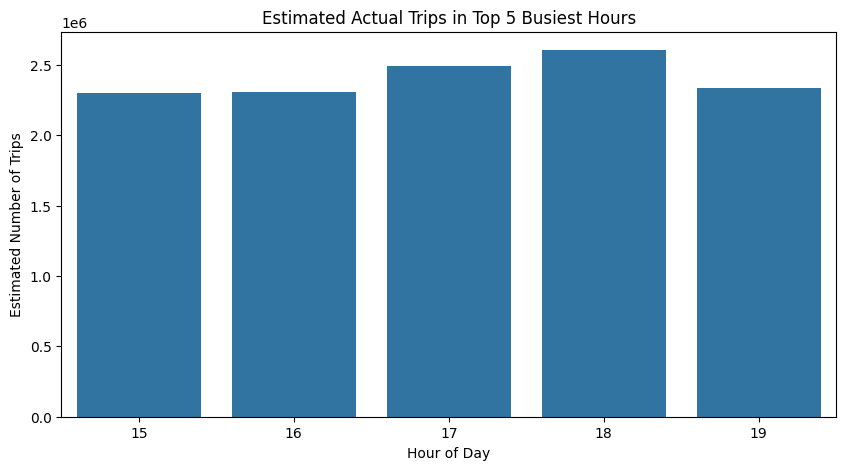

In [52]:
# =========================================================
# 3.2.3 Estimate actual number of trips
# in the five busiest hours
# =========================================================

# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.0075

# Scale up the number of trips

actual_trip_estimates = (
    top_hours / sample_fraction
).astype(int)

actual_trip_estimates

# converting to dataframe for better readability

actual_trip_estimates_df = (
    actual_trip_estimates
    .reset_index()
)

actual_trip_estimates_df.columns = [
    'pickup_hour',
    'estimated_actual_trips'
]

actual_trip_estimates_df

# visualising estimated actual trips

plt.figure(figsize=(10,5))

sns.barplot(
    data=actual_trip_estimates_df,

    x='pickup_hour',

    y='estimated_actual_trips'
)

plt.title('Estimated Actual Trips in Top 5 Busiest Hours')

plt.xlabel('Hour of Day')

plt.ylabel('Estimated Number of Trips')

plt.show()



**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

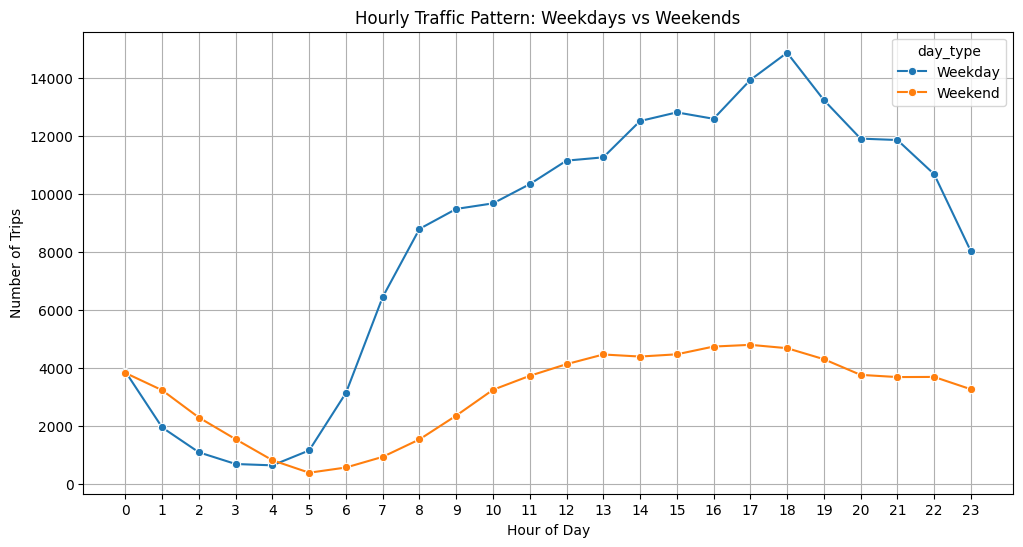

Weekday Peak Hour
    pickup_hour day_type  trip_count
36           18  Weekday       14854

Weekend Peak Hour
    pickup_hour day_type  trip_count
35           17  Weekend        4791


In [53]:
# =========================================================
# 3.2.4 Compare hourly traffic trends
# for weekdays and weekends
# =========================================================

# creating weekday/weekend flag

df['day_type'] = np.where(

    df['pickup_day'].isin(
        ['Saturday', 'Sunday']
    ),

    'Weekend',

    'Weekday'
)

# calculating trips by hour and day type

hourly_daytype_trips = (

    df.groupby(
        [
            'pickup_hour',
            'day_type'
        ]
    )

    .size()

    .reset_index(name='trip_count')
)

hourly_daytype_trips.head()

# Compare traffic trends for weekdays and weekends

plt.figure(figsize=(12,6))

sns.lineplot(

    data=hourly_daytype_trips,

    x='pickup_hour',

    y='trip_count',

    hue='day_type',

    marker='o'
)

plt.title('Hourly Traffic Pattern: Weekdays vs Weekends')

plt.xlabel('Hour of Day')

plt.ylabel('Number of Trips')

plt.xticks(range(0,24))

plt.grid(True)

plt.show()

# separate pivot view for better comparison

traffic_pivot = (

    hourly_daytype_trips

    .pivot(
        index='pickup_hour',
        columns='day_type',
        values='trip_count'
    )
)

traffic_pivot.head()

# calculating peak hours separately

weekday_peak_hour = (

    hourly_daytype_trips[
        hourly_daytype_trips['day_type'] == 'Weekday'
    ]

    .sort_values(
        by='trip_count',
        ascending=False
    )

    .head(1)
)

weekend_peak_hour = (

    hourly_daytype_trips[
        hourly_daytype_trips['day_type'] == 'Weekend'
    ]

    .sort_values(
        by='trip_count',
        ascending=False
    )

    .head(1)
)

print('Weekday Peak Hour')
print(weekday_peak_hour)

print('\nWeekend Peak Hour')
print(weekend_peak_hour)



What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

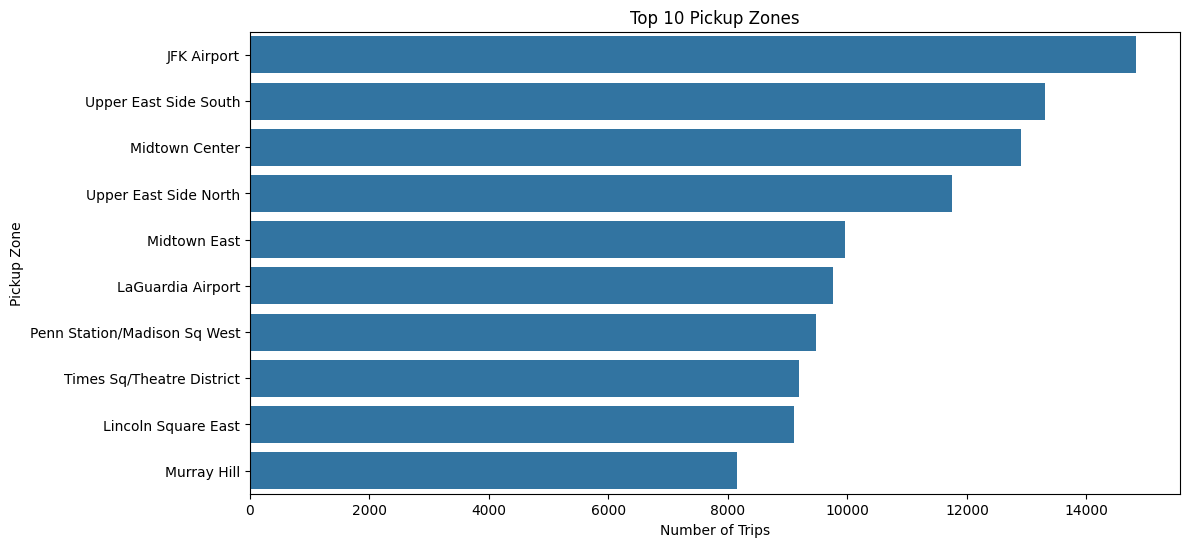

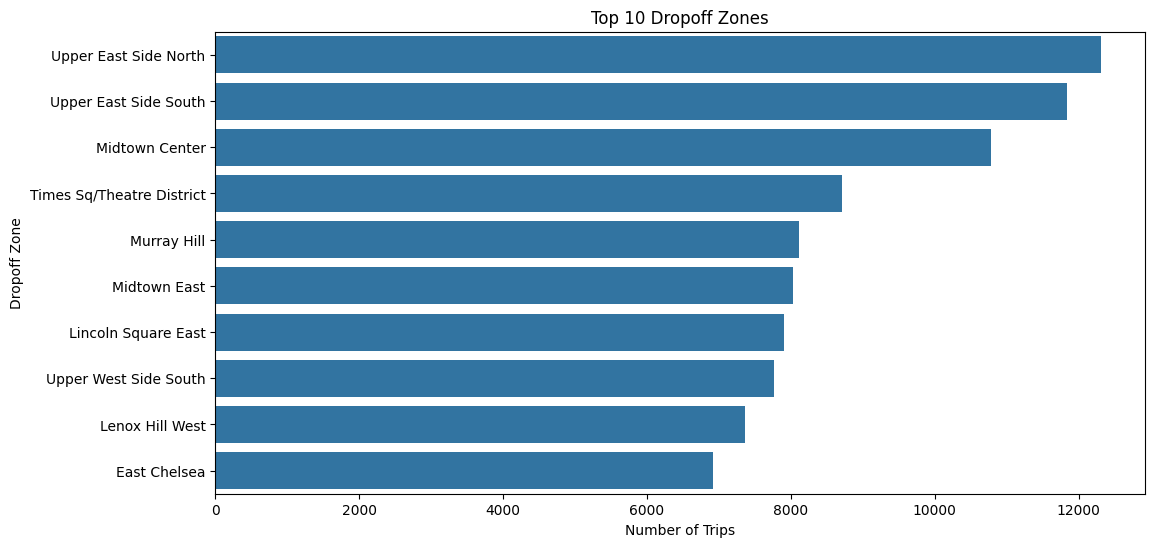

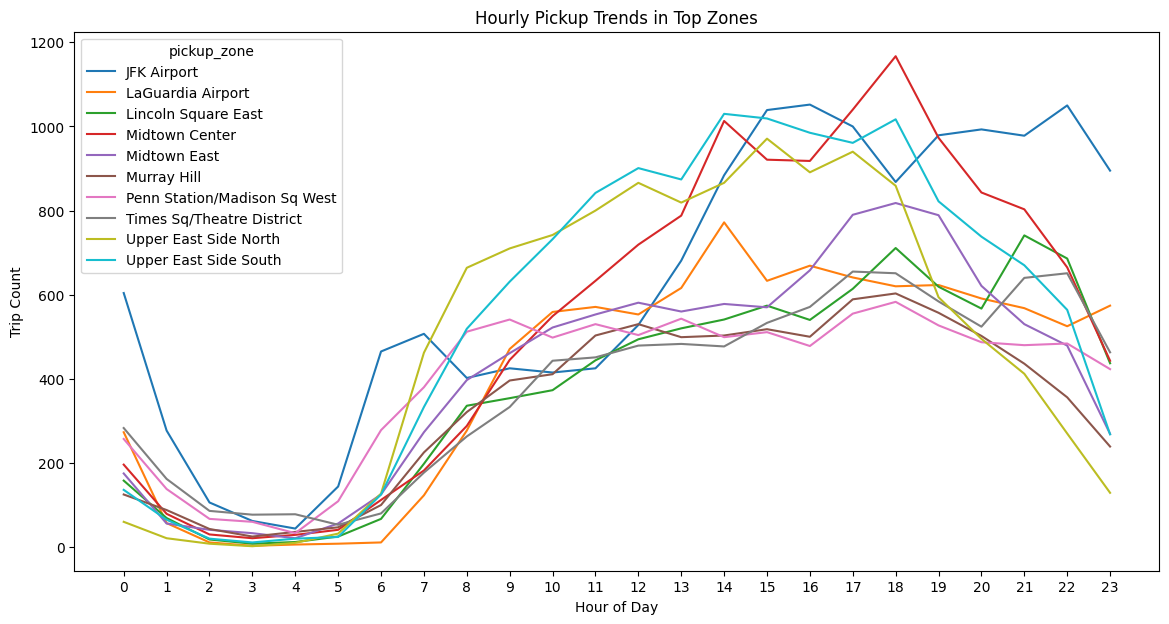

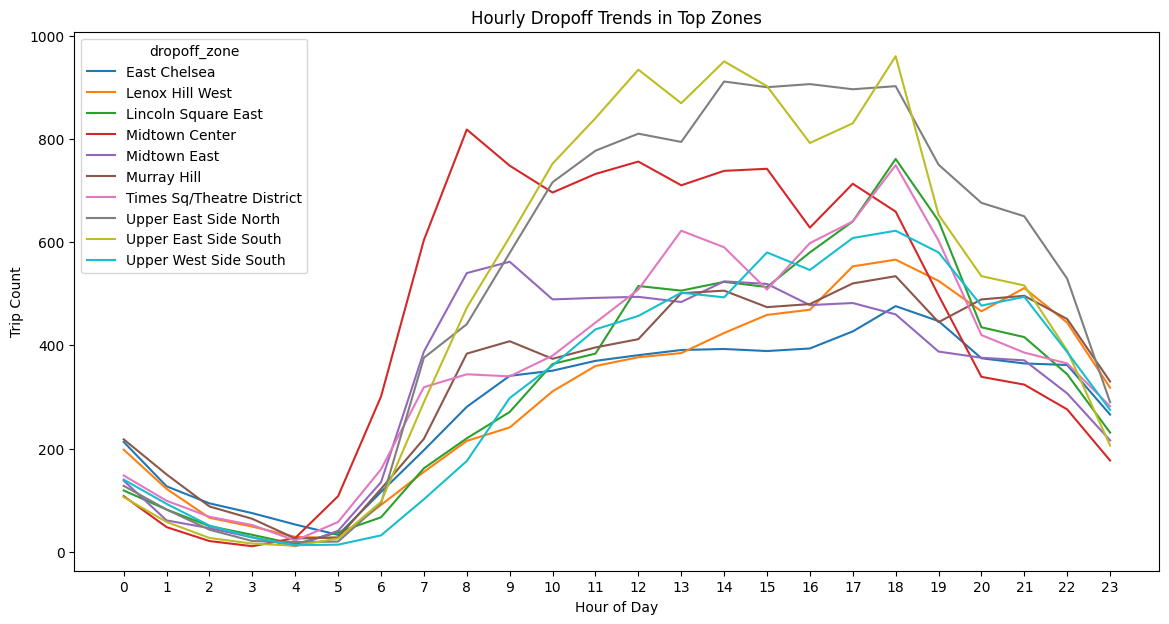

In [60]:
# =========================================================
# 3.2.5 Analyse top pickup and dropoff zones
# =========================================================

# Find top 10 pickup and dropoff zones

# Top 10 pickup zones

top_pickup_zones = (

    pickup_zones_df['pickup_zone']

    .value_counts()

    .head(10)
)

top_pickup_zones

# visualising top pickup zones

plt.figure(figsize=(12,6))

sns.barplot(

    x=top_pickup_zones.values,

    y=top_pickup_zones.index
)

plt.title('Top 10 Pickup Zones')

plt.xlabel('Number of Trips')

plt.ylabel('Pickup Zone')

plt.show()

# preparing dropoff zone merge

dropoff_zones_df = df.merge(

    zones[
        [
            'LocationID',
            'zone',
            'borough'
        ]
    ],

    left_on='dolocationid',
    right_on='LocationID',

    how='left'
)

# renaming columns

dropoff_zones_df.rename(

    columns={
        'zone':'dropoff_zone',
        'borough':'dropoff_borough'
    },

    inplace=True
)

# Top 10 dropoff zones

top_dropoff_zones = (

    dropoff_zones_df['dropoff_zone']

    .value_counts()

    .head(10)
)

top_dropoff_zones

# visualising top dropoff zones

plt.figure(figsize=(12,6))

sns.barplot(

    x=top_dropoff_zones.values,

    y=top_dropoff_zones.index
)

plt.title('Top 10 Dropoff Zones')

plt.xlabel('Number of Trips')

plt.ylabel('Dropoff Zone')

plt.show()

# analysing hourly pickup trends
# for top pickup zones

pickup_hourly_trend = (

    pickup_zones_df[
        pickup_zones_df['pickup_zone']
        .isin(top_pickup_zones.index)
    ]

    .groupby(
        [
            'pickup_hour',
            'pickup_zone'
        ]
    )

    .size()

    .reset_index(name='trip_count')
)

# plotting hourly pickup trends

plt.figure(figsize=(14,7))

sns.lineplot(

    data=pickup_hourly_trend,

    x='pickup_hour',

    y='trip_count',

    hue='pickup_zone'
)

plt.title('Hourly Pickup Trends in Top Zones')

plt.xlabel('Hour of Day')

plt.ylabel('Trip Count')

plt.xticks(range(0,24))

plt.show()

# analysing hourly dropoff trends
# for top dropoff zones

dropoff_hourly_trend = (

    dropoff_zones_df[
        dropoff_zones_df['dropoff_zone']
        .isin(top_dropoff_zones.index)
    ]

    .groupby(
        [
            'pickup_hour',
            'dropoff_zone'
        ]
    )

    .size()

    .reset_index(name='trip_count')
)

# plotting hourly dropoff trends

plt.figure(figsize=(14,7))

sns.lineplot(

    data=dropoff_hourly_trend,

    x='pickup_hour',

    y='trip_count',

    hue='dropoff_zone'
)

plt.title('Hourly Dropoff Trends in Top Zones')

plt.xlabel('Hour of Day')

plt.ylabel('Trip Count')

plt.xticks(range(0,24))

plt.show()


**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

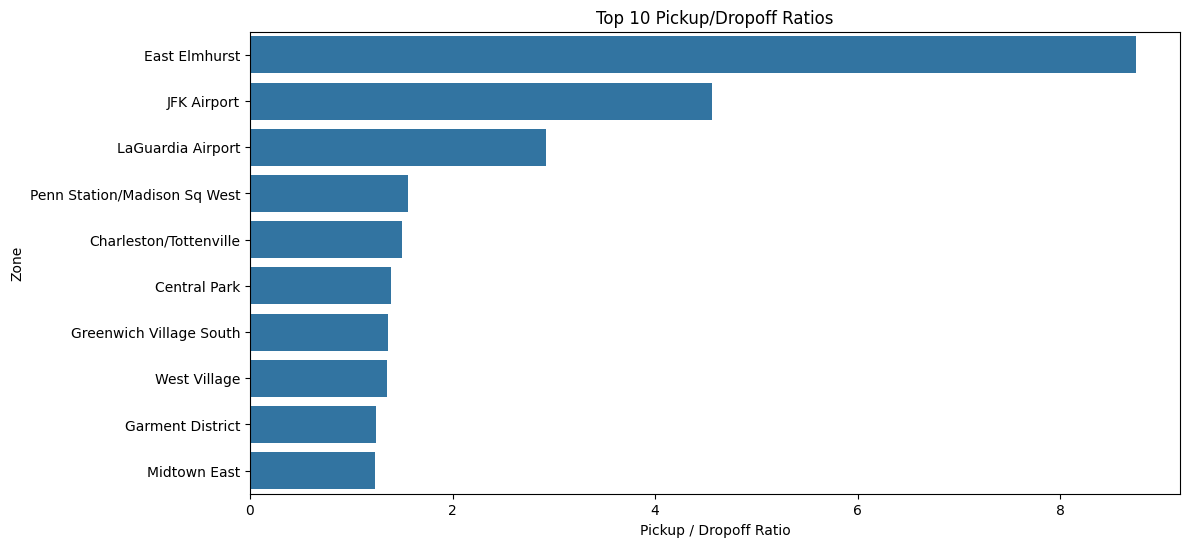

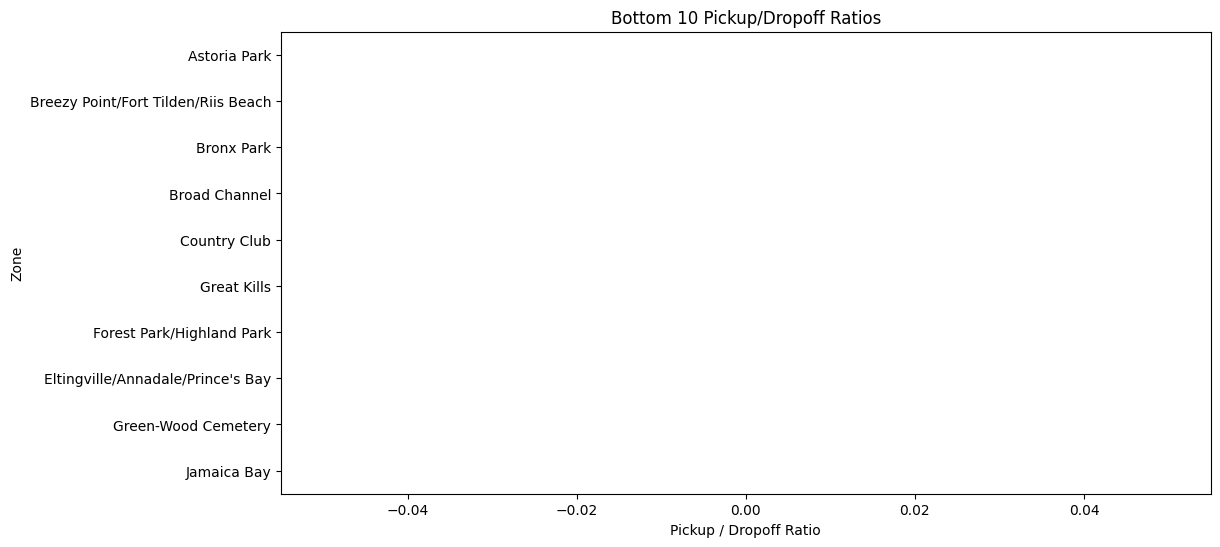

In [61]:
# =========================================================
# 3.2.6 Pickup / Dropoff Ratio Analysis
# =========================================================

# Find the top 10 and bottom 10 pickup/dropoff ratios
# calculating pickup counts by zone

pickup_counts = (

    pickup_zones_df['pickup_zone']

    .value_counts()

    .reset_index()
)

pickup_counts.columns = [
    'zone',
    'pickup_count'
]

pickup_counts.head()

# calculating dropoff counts by zone

dropoff_counts = (

    dropoff_zones_df['dropoff_zone']

    .value_counts()

    .reset_index()
)

dropoff_counts.columns = [
    'zone',
    'dropoff_count'
]

dropoff_counts.head()

# merging pickup and dropoff counts

pickup_drop_ratio = pd.merge(

    pickup_counts,

    dropoff_counts,

    on='zone',

    how='outer'
)

# filling missing values

pickup_drop_ratio.fillna(0, inplace=True)

# calculating pickup/dropoff ratio

pickup_drop_ratio['pickup_drop_ratio'] = (

    pickup_drop_ratio['pickup_count'] /

    (pickup_drop_ratio['dropoff_count'] + 1)
)

# sorting highest ratios

top_ratios = (

    pickup_drop_ratio

    .sort_values(
        by='pickup_drop_ratio',
        ascending=False
    )

    .head(10)
)

top_ratios

# sorting lowest ratios

bottom_ratios = (

    pickup_drop_ratio

    .sort_values(
        by='pickup_drop_ratio',
        ascending=True
    )

    .head(10)
)

bottom_ratios

# visualising top pickup/dropoff ratios

plt.figure(figsize=(12,6))

sns.barplot(

    data=top_ratios,

    x='pickup_drop_ratio',

    y='zone'
)

plt.title('Top 10 Pickup/Dropoff Ratios')

plt.xlabel('Pickup / Dropoff Ratio')

plt.ylabel('Zone')

plt.show()

# visualising bottom pickup/dropoff ratios

plt.figure(figsize=(12,6))

sns.barplot(

    data=bottom_ratios,

    x='pickup_drop_ratio',

    y='zone'
)

plt.title('Bottom 10 Pickup/Dropoff Ratios')

plt.xlabel('Pickup / Dropoff Ratio')

plt.ylabel('Zone')

plt.show()



**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

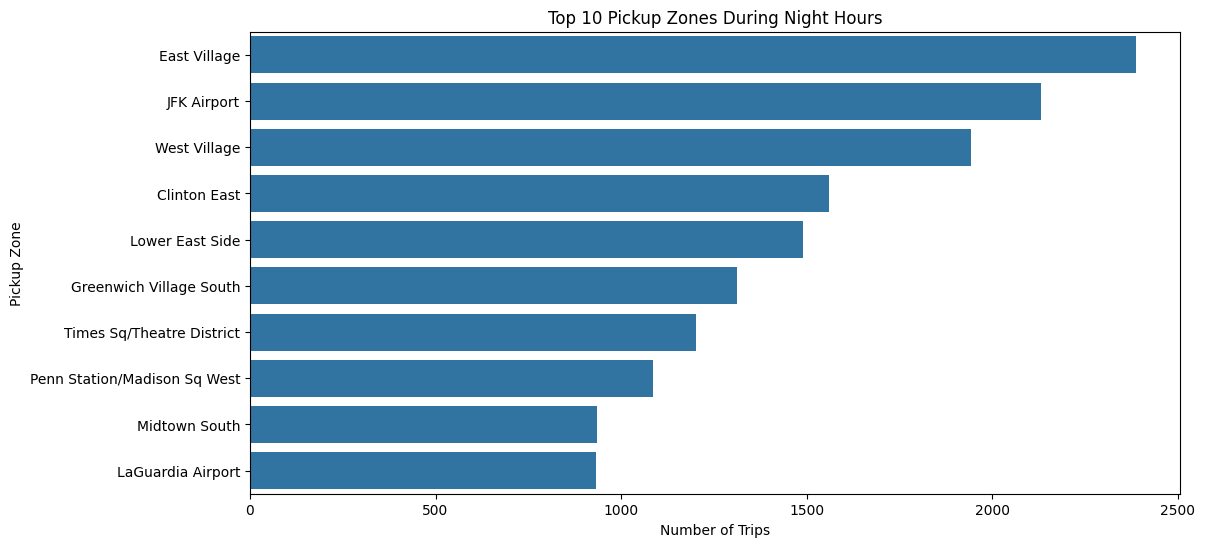

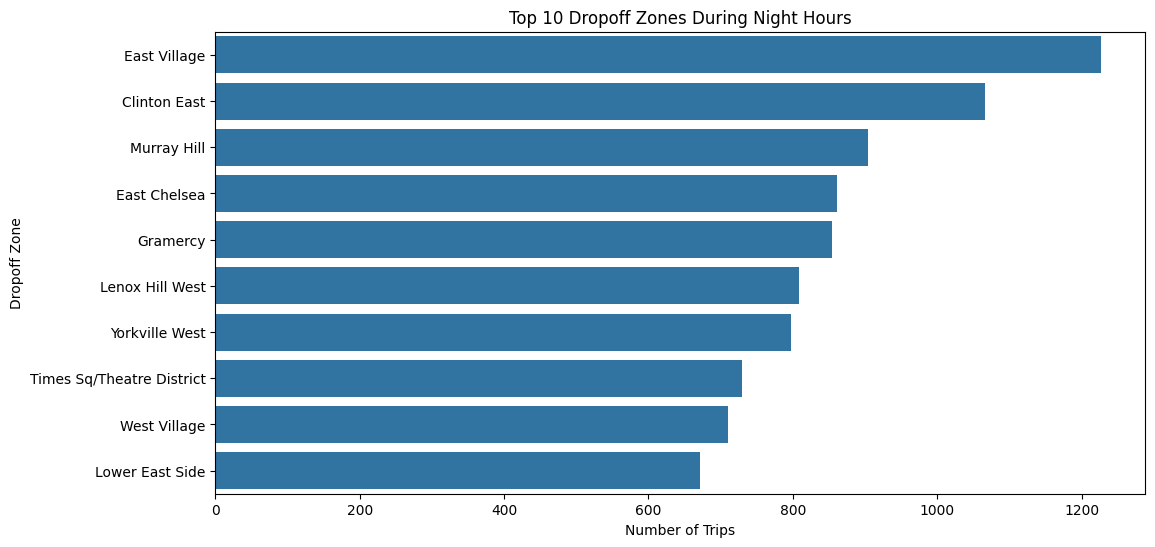

,Night_Pickups,Night_Dropoffs
Clinton East,1561.0,1067.0
East Chelsea,NaN,861.0
East Village,2386.0,1227.0
Gramercy,NaN,854.0
Greenwich Village South,1311.0,NaN
JFK Airport,2132.0,NaN
LaGuardia Airport,932.0,NaN
Lenox Hill West,NaN,809.0
Lower East Side,1491.0,672.0
Midtown South,934.0,NaN


In [62]:
# =========================================================
# 3.2.7 Night Hour Pickup and Dropoff Analysis
# =========================================================

# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

# defining night hours
# 11 PM to 5 AM

night_hours = [23, 0, 1, 2, 3, 4, 5]


# filtering pickup records for night hours

night_pickups = pickup_zones_df[

    pickup_zones_df['pickup_hour']
    .isin(night_hours)
]

# top 10 pickup zones during night hours

night_pickup_zones = (

    night_pickups['pickup_zone']

    .value_counts()

    .head(10)
)

night_pickup_zones

# visualising night pickup zones

plt.figure(figsize=(12,6))

sns.barplot(

    x=night_pickup_zones.values,

    y=night_pickup_zones.index
)

plt.title('Top 10 Pickup Zones During Night Hours')

plt.xlabel('Number of Trips')

plt.ylabel('Pickup Zone')

plt.show()

# filtering dropoff records for night hours

night_dropoffs = dropoff_zones_df[

    dropoff_zones_df['pickup_hour']
    .isin(night_hours)
]

# top 10 dropoff zones during night hours

night_dropoff_zones = (

    night_dropoffs['dropoff_zone']

    .value_counts()

    .head(10)
)

night_dropoff_zones

# visualising night dropoff zones

plt.figure(figsize=(12,6))

sns.barplot(

    x=night_dropoff_zones.values,

    y=night_dropoff_zones.index
)

plt.title('Top 10 Dropoff Zones During Night Hours')

plt.xlabel('Number of Trips')

plt.ylabel('Dropoff Zone')

plt.show()

# comparing pickup vs dropoff night activity

night_activity_comparison = pd.DataFrame({

    'Night_Pickups': night_pickup_zones,

    'Night_Dropoffs': night_dropoff_zones
})

night_activity_comparison




Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

Night Revenue : 963728.84
Day Revenue : 7047187.56
Overall Revenue : 8010916.4

Night Revenue Share : 12.03 %
Day Revenue Share : 87.97 %


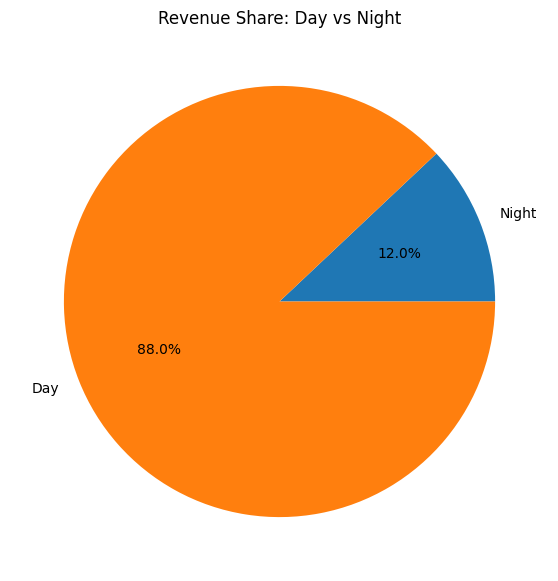

In [63]:
# =========================================================
# 3.2.8 Revenue Share:
# Nighttime vs Daytime
# =========================================================
# Filter for night hours (11 PM to 5 AM)

night_hours = [23, 0, 1, 2, 3, 4, 5]

night_df = df[

    df['pickup_hour']
    .isin(night_hours)
]

# creating daytime dataframe

day_df = df[

    ~df['pickup_hour']
    .isin(night_hours)
]

# calculating total revenue

night_revenue = (
    night_df['total_amount']
    .sum()
)

day_revenue = (
    day_df['total_amount']
    .sum()
)

overall_revenue = (
    df['total_amount']
    .sum()
)

# calculating revenue share percentages

night_revenue_share = (

    night_revenue /

    overall_revenue
) * 100

day_revenue_share = (

    day_revenue /

    overall_revenue
) * 100


# displaying revenue statistics

print('Night Revenue :', round(night_revenue, 2))

print('Day Revenue :', round(day_revenue, 2))

print('Overall Revenue :', round(overall_revenue, 2))

print('\nNight Revenue Share :',
      round(night_revenue_share, 2), '%')

print('Day Revenue Share :',
      round(day_revenue_share, 2), '%')

# visualising revenue share

revenue_share_df = pd.DataFrame({

    'Time_Period':['Night', 'Day'],

    'Revenue_Share':[
        night_revenue_share,
        day_revenue_share
    ]
})

revenue_share_df

# plotting revenue share

plt.figure(figsize=(7,7))

plt.pie(

    revenue_share_df['Revenue_Share'],

    labels=revenue_share_df['Time_Period'],

    autopct='%1.1f%%'
)

plt.title('Revenue Share: Day vs Night')

plt.show()



##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

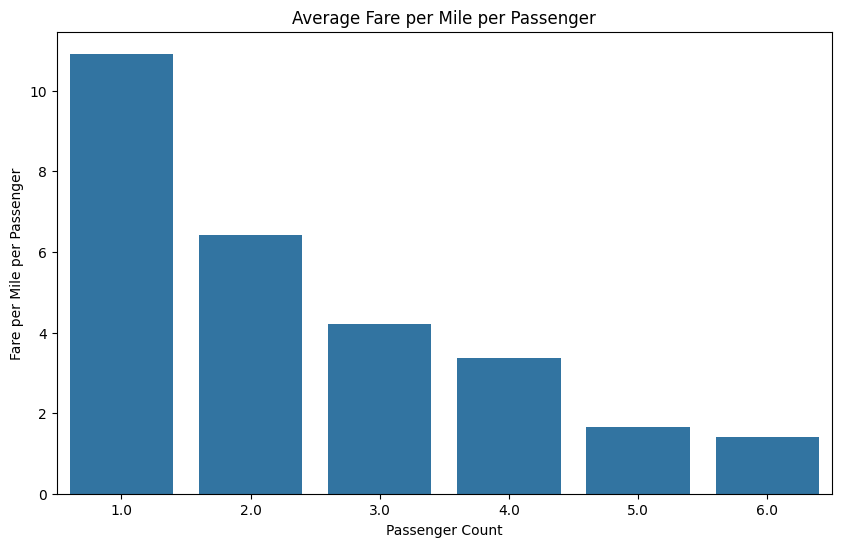

Most economical passenger group :
passenger_count                6.00
fare_per_mile_per_passenger    1.41
Name: 5, dtype: float64


In [64]:
# =========================================================
# 3.2.9 Pricing Strategy Analysis
# Fare per Mile per Passenger
# =========================================================
# Analyse the fare per mile per passenger for different passenger counts
# creating a clean dataframe for pricing analysis

pricing_df = df.copy()


# removing invalid entries

pricing_df = pricing_df[

    (pricing_df['trip_distance'] > 0) &

    (pricing_df['fare_amount'] > 0) &

    (pricing_df['passenger_count'] > 0)
]

# calculating fare per mile

pricing_df['fare_per_mile'] = (

    pricing_df['fare_amount'] /

    pricing_df['trip_distance']
)

# calculating fare per mile per passenger

pricing_df['fare_per_mile_per_passenger'] = (

    pricing_df['fare_per_mile'] /

    pricing_df['passenger_count']
)

# grouping by passenger count

passenger_pricing = (

    pricing_df.groupby('passenger_count')

    .agg({
        'fare_per_mile_per_passenger':'mean'
    })

    .reset_index()
)

passenger_pricing

# rounding values for readability

passenger_pricing[
    'fare_per_mile_per_passenger'
] = (

    passenger_pricing[
        'fare_per_mile_per_passenger'
    ]

    .round(2)
)

passenger_pricing

# visualising pricing trend

plt.figure(figsize=(10,6))

sns.barplot(

    data=passenger_pricing,

    x='passenger_count',

    y='fare_per_mile_per_passenger'
)

plt.title('Average Fare per Mile per Passenger')

plt.xlabel('Passenger Count')

plt.ylabel('Fare per Mile per Passenger')

plt.show()

# identifying most economical category

best_value = passenger_pricing.loc[

    passenger_pricing[
        'fare_per_mile_per_passenger'
    ].idxmin()
]

print('Most economical passenger group :')

print(best_value)





**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

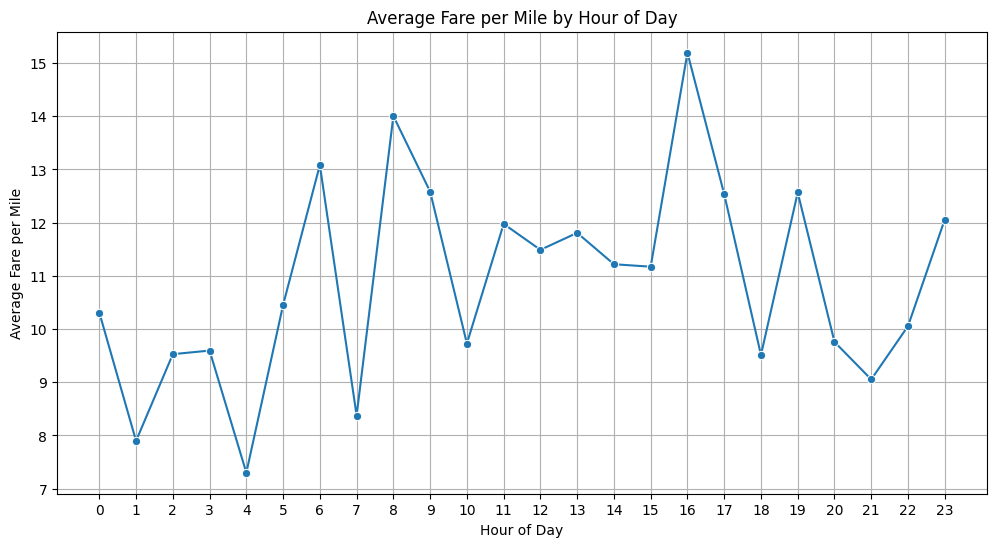

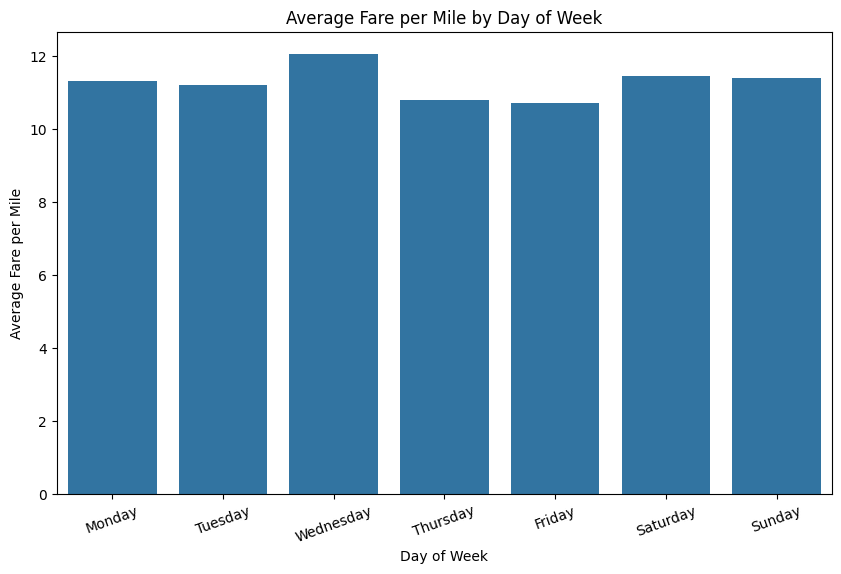

Highest Fare per Mile Hour
pickup_hour      16.000000
fare_per_mile    15.194766
Name: 16, dtype: float64

Highest Fare per Mile Day
pickup_day       Wednesday
fare_per_mile    12.053124
Name: 6, dtype: object


In [65]:
# =========================================================
# 3.2.10 Average Fare per Mile Analysis
# by Hour and Day of Week
# =========================================================
# Compare the average fare per mile for different days and for different times of the day

# creating clean dataframe for fare analysis

fare_analysis_df = df.copy()

# removing invalid distance and fare values

fare_analysis_df = fare_analysis_df[

    (fare_analysis_df['trip_distance'] > 0) &

    (fare_analysis_df['fare_amount'] > 0)
]

# calculating fare per mile

fare_analysis_df['fare_per_mile'] = (

    fare_analysis_df['fare_amount'] /

    fare_analysis_df['trip_distance']
)

# average fare per mile by pickup hour

hourly_fare_per_mile = (

    fare_analysis_df.groupby('pickup_hour')

    .agg({
        'fare_per_mile':'mean'
    })

    .reset_index()
)

hourly_fare_per_mile.head()

# plotting hourly fare trend

plt.figure(figsize=(12,6))

sns.lineplot(

    data=hourly_fare_per_mile,

    x='pickup_hour',

    y='fare_per_mile',

    marker='o'
)

plt.title('Average Fare per Mile by Hour of Day')

plt.xlabel('Hour of Day')

plt.ylabel('Average Fare per Mile')

plt.xticks(range(0,24))

plt.grid(True)

plt.show()

# average fare per mile by day of week

daily_fare_per_mile = (

    fare_analysis_df.groupby('pickup_day')

    .agg({
        'fare_per_mile':'mean'
    })

    .reset_index()
)

daily_fare_per_mile

# ordering weekdays properly

day_order = [

    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

daily_fare_per_mile['pickup_day'] = pd.Categorical(

    daily_fare_per_mile['pickup_day'],

    categories=day_order,

    ordered=True
)

daily_fare_per_mile = (

    daily_fare_per_mile
    .sort_values('pickup_day')
)

# plotting daily fare trend

plt.figure(figsize=(10,6))

sns.barplot(

    data=daily_fare_per_mile,

    x='pickup_day',

    y='fare_per_mile'
)

plt.title('Average Fare per Mile by Day of Week')

plt.xlabel('Day of Week')

plt.ylabel('Average Fare per Mile')

plt.xticks(rotation=20)

plt.show()

# identifying peak pricing periods

highest_hour = hourly_fare_per_mile.loc[

    hourly_fare_per_mile['fare_per_mile'].idxmax()
]

highest_day = daily_fare_per_mile.loc[

    daily_fare_per_mile['fare_per_mile'].idxmax()
]

print('Highest Fare per Mile Hour')
print(highest_hour)

print('\nHighest Fare per Mile Day')
print(highest_day)



**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

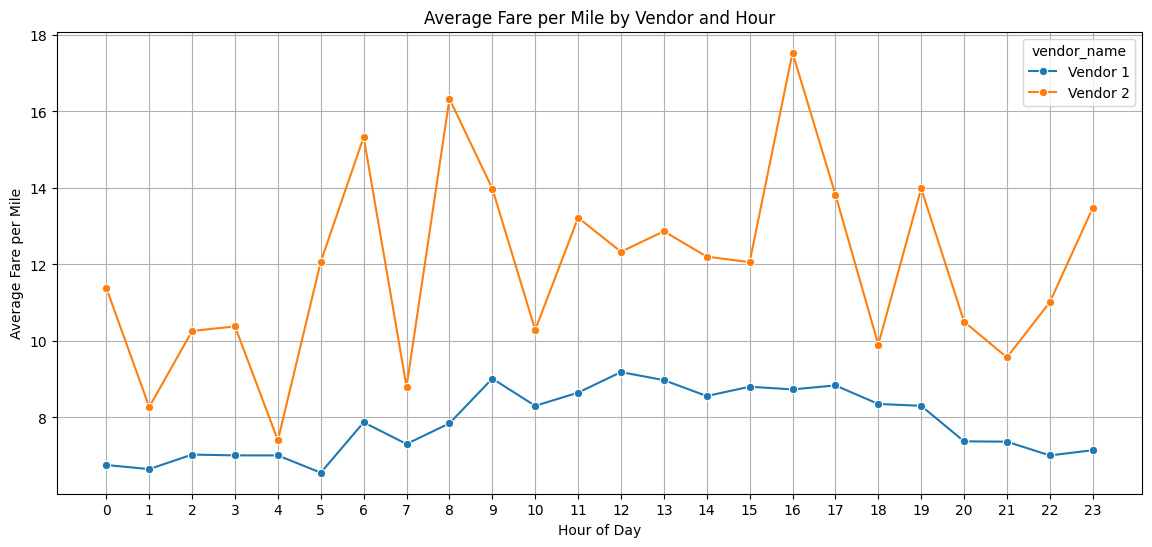

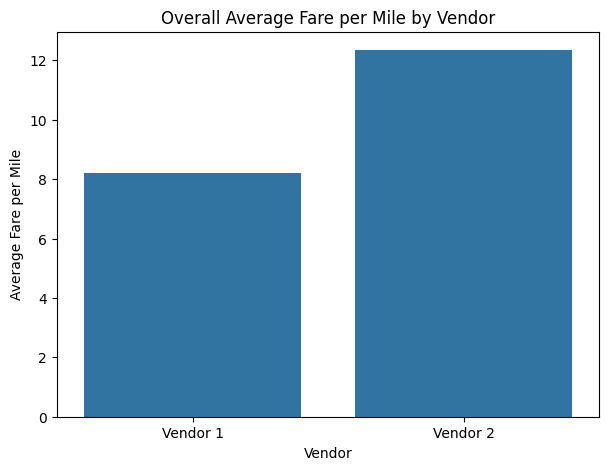

Vendor with higher average fare per mile
vendor_name       Vendor 2
fare_per_mile    12.344398
Name: 1, dtype: object


In [66]:
# =========================================================
# 3.2.11 Vendor-wise Fare per Mile Analysis
# =========================================================
# Compare fare per mile for different vendors
# creating dataframe for vendor pricing analysis

vendor_df = df.copy()

# removing invalid entries

vendor_df = vendor_df[

    (vendor_df['trip_distance'] > 0) &

    (vendor_df['fare_amount'] > 0)
]

# calculating fare per mile

vendor_df['fare_per_mile'] = (

    vendor_df['fare_amount'] /

    vendor_df['trip_distance']
)

# mapping vendor ids for readability

vendor_map = {

    1:'Vendor 1',

    2:'Vendor 2'
}

vendor_df['vendor_name'] = (

    vendor_df['vendorid']
    .map(vendor_map)
)

# average fare per mile by vendor and pickup hour

vendor_hourly_fare = (

    vendor_df.groupby(
        [
            'pickup_hour',
            'vendor_name'
        ]
    )

    .agg({
        'fare_per_mile':'mean'
    })

    .reset_index()
)

vendor_hourly_fare.head()

# visualising vendor pricing trends

plt.figure(figsize=(14,6))

sns.lineplot(

    data=vendor_hourly_fare,

    x='pickup_hour',

    y='fare_per_mile',

    hue='vendor_name',

    marker='o'
)

plt.title('Average Fare per Mile by Vendor and Hour')

plt.xlabel('Hour of Day')

plt.ylabel('Average Fare per Mile')

plt.xticks(range(0,24))

plt.grid(True)

plt.show()

# comparing overall average fare per mile by vendor

vendor_summary = (

    vendor_df.groupby('vendor_name')

    .agg({
        'fare_per_mile':'mean'
    })

    .reset_index()
)

vendor_summary

# visualising overall vendor comparison

plt.figure(figsize=(7,5))

sns.barplot(

    data=vendor_summary,

    x='vendor_name',

    y='fare_per_mile'
)

plt.title('Overall Average Fare per Mile by Vendor')

plt.xlabel('Vendor')

plt.ylabel('Average Fare per Mile')

plt.show()

# identifying higher priced vendor

highest_vendor = vendor_summary.loc[

    vendor_summary['fare_per_mile'].idxmax()
]

print('Vendor with higher average fare per mile')

print(highest_vendor)




**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


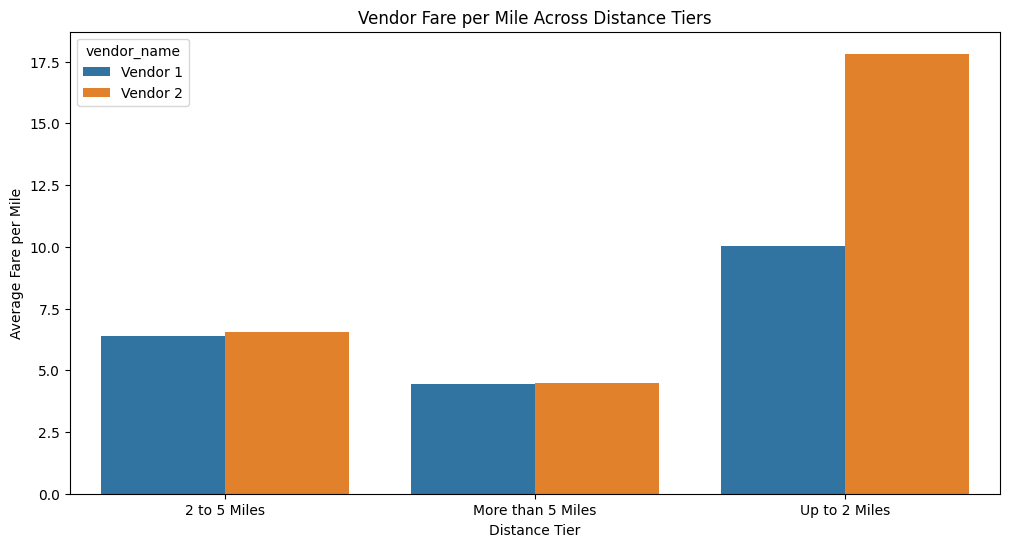

vendor_name,Vendor 1,Vendor 2
distance_tier,,
2 to 5 Miles,6.38,6.54
More than 5 Miles,4.44,4.50
Up to 2 Miles,10.04,17.82


In [67]:
# =========================================================
# 3.2.12 Vendor Fare Comparison by Distance Tier
# =========================================================

# Defining distance tiers

## creating dataframe for tier analysis

tier_df = df.copy()

# removing invalid values

tier_df = tier_df[

    (tier_df['trip_distance'] > 0) &

    (tier_df['fare_amount'] > 0)
]

# calculating fare per mile

tier_df['fare_per_mile'] = (

    tier_df['fare_amount'] /

    tier_df['trip_distance']
)

# mapping vendor names

vendor_map = {

    1:'Vendor 1',

    2:'Vendor 2'
}

tier_df['vendor_name'] = (

    tier_df['vendorid']
    .map(vendor_map)
)

# Defining distance tiers

def distance_tier(distance):

    if distance <= 2:
        return 'Up to 2 Miles'

    elif 2 < distance <= 5:
        return '2 to 5 Miles'

    else:
        return 'More than 5 Miles'

tier_df['distance_tier'] = (

    tier_df['trip_distance']
    .apply(distance_tier)
)

# checking tier distribution

tier_df['distance_tier'].value_counts()

# calculating average fare per mile
# by vendor and distance tier

vendor_tier_pricing = (

    tier_df.groupby(
        [
            'vendor_name',
            'distance_tier'
        ]
    )

    .agg({
        'fare_per_mile':'mean'
    })

    .reset_index()
)

vendor_tier_pricing

# rounding values

vendor_tier_pricing['fare_per_mile'] = (

    vendor_tier_pricing['fare_per_mile']
    .round(2)
)

vendor_tier_pricing

# visualising vendor pricing by distance tier

plt.figure(figsize=(12,6))

sns.barplot(

    data=vendor_tier_pricing,

    x='distance_tier',

    y='fare_per_mile',

    hue='vendor_name'
)

plt.title('Vendor Fare per Mile Across Distance Tiers')

plt.xlabel('Distance Tier')

plt.ylabel('Average Fare per Mile')

plt.show()

# pivot table for easier comparison

vendor_tier_pivot = (

    vendor_tier_pricing

    .pivot(
        index='distance_tier',
        columns='vendor_name',
        values='fare_per_mile'
    )
)

vendor_tier_pivot



##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

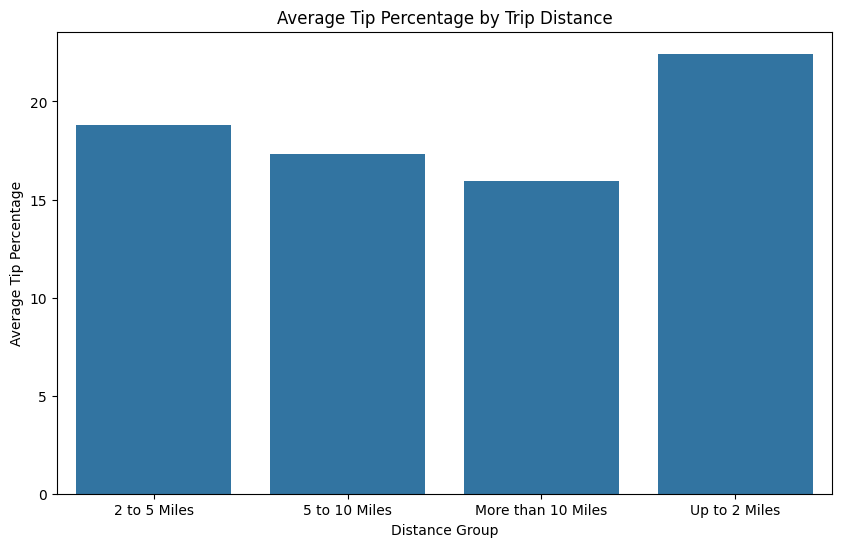

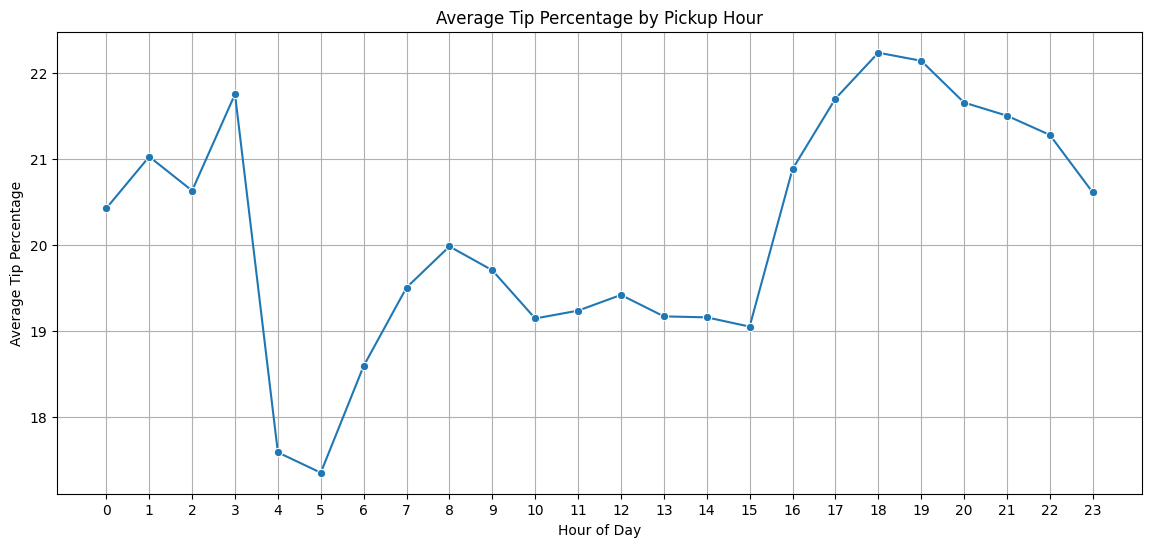

In [68]:
# =========================================================
# 3.2.13 Customer Experience Analysis
# Tip Percentage Behaviour
# =========================================================
#  Analyze tip percentages based on distances, passenger counts and pickup times
# creating dataframe for tip analysis

tip_df = df.copy()

# removing invalid entries

tip_df = tip_df[

    (tip_df['fare_amount'] > 0) &

    (tip_df['trip_distance'] > 0)
]

# calculating tip percentage

tip_df['tip_percentage'] = (

    tip_df['tip_amount'] /

    tip_df['fare_amount']
) * 100

# Tip % by Distance
# creating distance categories

def trip_distance_group(distance):

    if distance <= 2:
        return 'Up to 2 Miles'

    elif distance <= 5:
        return '2 to 5 Miles'

    elif distance <= 10:
        return '5 to 10 Miles'

    else:
        return 'More than 10 Miles'

tip_df['distance_group'] = (

    tip_df['trip_distance']
    .apply(trip_distance_group)
)

# average tip percentage by distance

distance_tip_analysis = (

    tip_df.groupby('distance_group')

    .agg({
        'tip_percentage':'mean'
    })

    .reset_index()
)

distance_tip_analysis

# plotting distance vs tip percentage

plt.figure(figsize=(10,6))

sns.barplot(

    data=distance_tip_analysis,

    x='distance_group',

    y='tip_percentage'
)

plt.title('Average Tip Percentage by Trip Distance')

plt.xlabel('Distance Group')

plt.ylabel('Average Tip Percentage')

plt.show()

# Tip % by Passenger Count

# average tip percentage by passenger count

passenger_tip_analysis = (

    tip_df.groupby('passenger_count')

    .agg({
        'tip_percentage':'mean'
    })

    .reset_index()
)

passenger_tip_analysis

# average tip percentage by passenger count

passenger_tip_analysis = (

    tip_df.groupby('passenger_count')

    .agg({
        'tip_percentage':'mean'
    })

    .reset_index()
)

passenger_tip_analysis

# Tip % by Pickup Hour

# average tip percentage by pickup hour

hourly_tip_analysis = (

    tip_df.groupby('pickup_hour')

    .agg({
        'tip_percentage':'mean'
    })

    .reset_index()
)

hourly_tip_analysis.head()

# plotting hourly tip behaviour

plt.figure(figsize=(14,6))

sns.lineplot(

    data=hourly_tip_analysis,

    x='pickup_hour',

    y='tip_percentage',

    marker='o'
)

plt.title('Average Tip Percentage by Pickup Hour')

plt.xlabel('Hour of Day')

plt.ylabel('Average Tip Percentage')

plt.xticks(range(0,24))

plt.grid(True)

plt.show()



Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [69]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%
# Low Tip vs High Tip Comparison

# low tip trips

low_tip_df = tip_df[

    tip_df['tip_percentage'] < 10
]

# high tip trips

high_tip_df = tip_df[

    tip_df['tip_percentage'] > 25
]

# comparing averages

comparison_summary = pd.DataFrame({

    'Metric':[
        'Average Distance',
        'Average Fare',
        'Average Passenger Count',
        'Average Trip Duration'
    ],

    'Low Tip Trips':[

        low_tip_df['trip_distance'].mean(),

        low_tip_df['fare_amount'].mean(),

        low_tip_df['passenger_count'].mean(),

        low_tip_df['trip_duration'].mean()
    ],

    'High Tip Trips':[

        high_tip_df['trip_distance'].mean(),

        high_tip_df['fare_amount'].mean(),

        high_tip_df['passenger_count'].mean(),

        high_tip_df['trip_duration'].mean()
    ]
})

comparison_summary

# rounding comparison table

comparison_summary[
    ['Low Tip Trips', 'High Tip Trips']
] = (

    comparison_summary[
        ['Low Tip Trips', 'High Tip Trips']
    ]

    .round(2)
)

comparison_summary

# counts of low and high tip trips

print('Low Tip Trips :',
      low_tip_df.shape[0])

print('High Tip Trips :',
      high_tip_df.shape[0])


Low Tip Trips : 70876
High Tip Trips : 122893


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

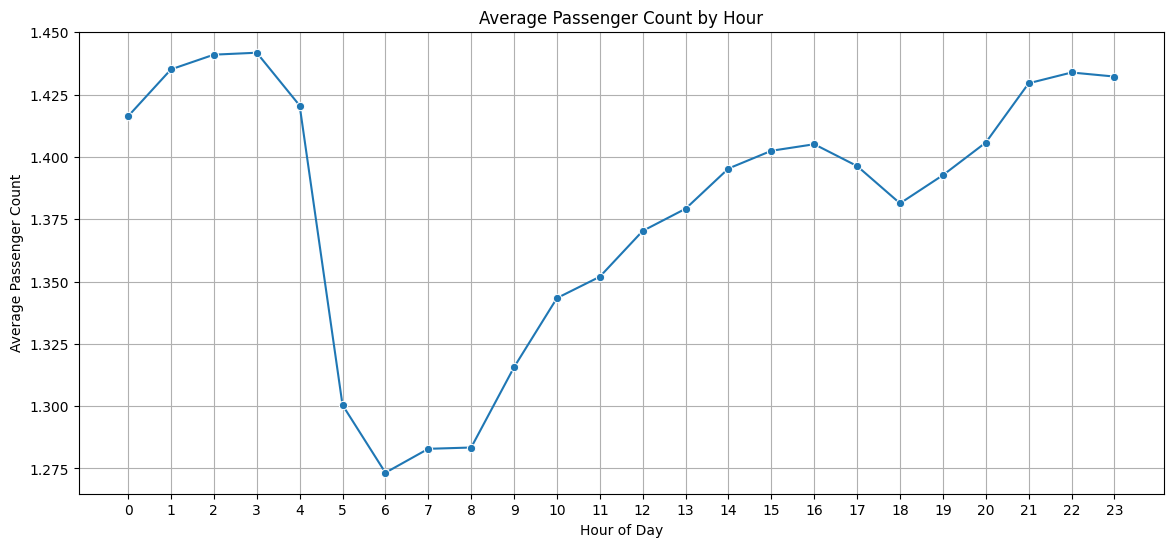

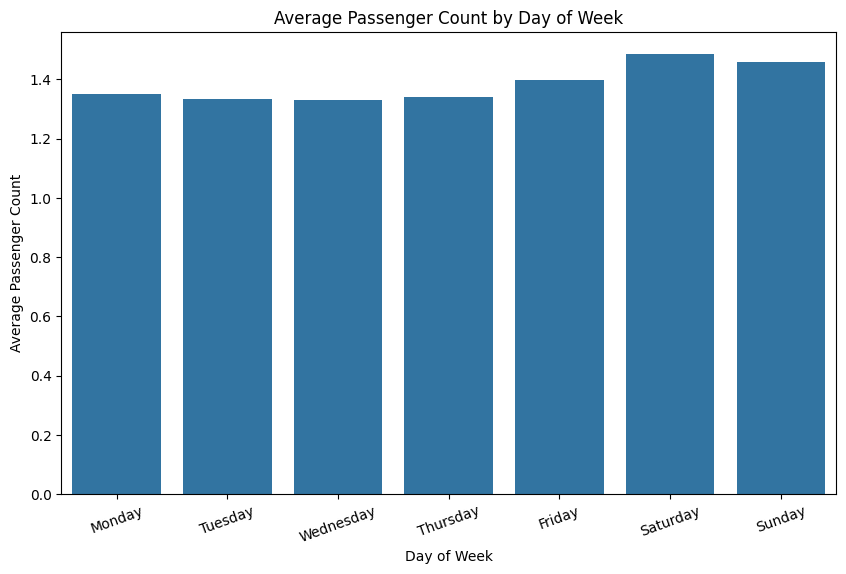

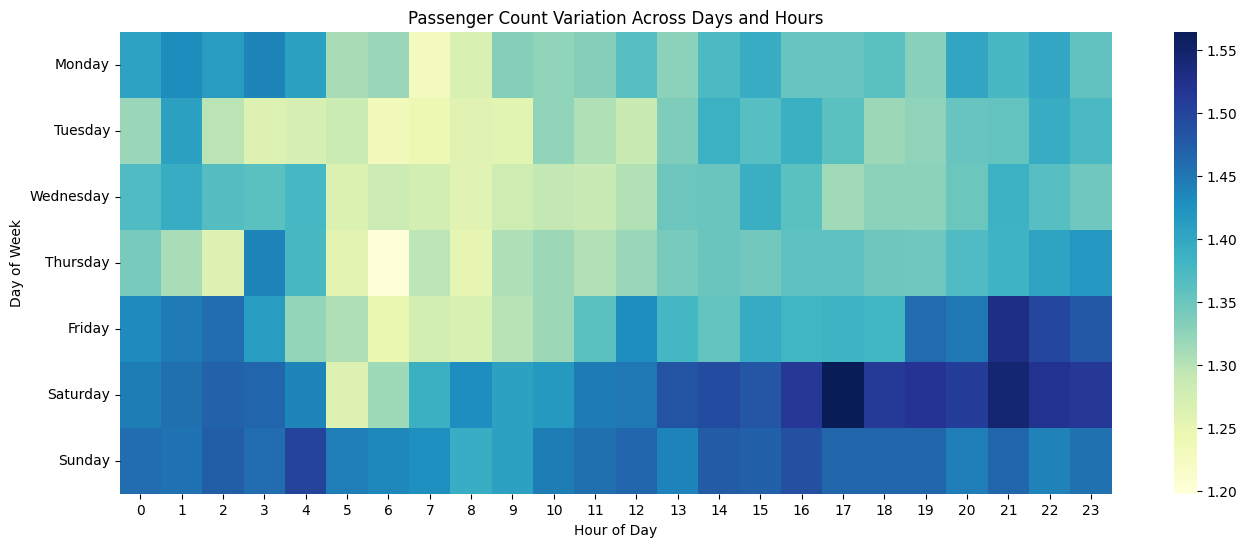

Highest Average Passenger Count Hour
pickup_hour        3.000000
passenger_count    1.441798
Name: 3, dtype: float64

Highest Average Passenger Count Day
pickup_day         Saturday
passenger_count     1.48591
Name: 2, dtype: object


In [70]:
# =========================================================
# 3.2.14 Passenger Count Variation Analysis
# =========================================================
# See how passenger count varies across hours and days

# creating dataframe for passenger analysis

passenger_df = df.copy()

# removing invalid passenger counts

passenger_df = passenger_df[

    passenger_df['passenger_count'] > 0
]

# Passenger Count by Hour
# average passenger count by hour

hourly_passenger_analysis = (

    passenger_df.groupby('pickup_hour')

    .agg({
        'passenger_count':'mean'
    })

    .reset_index()
)

hourly_passenger_analysis.head()

# plotting passenger trends by hour

plt.figure(figsize=(14,6))

sns.lineplot(

    data=hourly_passenger_analysis,

    x='pickup_hour',

    y='passenger_count',

    marker='o'
)

plt.title('Average Passenger Count by Hour')

plt.xlabel('Hour of Day')

plt.ylabel('Average Passenger Count')

plt.xticks(range(0,24))

plt.grid(True)

plt.show()

# Passenger Count by Day of Week
# average passenger count by weekday

daily_passenger_analysis = (

    passenger_df.groupby('pickup_day')

    .agg({
        'passenger_count':'mean'
    })

    .reset_index()
)

daily_passenger_analysis

# ordering weekdays properly

day_order = [

    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

daily_passenger_analysis['pickup_day'] = pd.Categorical(

    daily_passenger_analysis['pickup_day'],

    categories=day_order,

    ordered=True
)

daily_passenger_analysis = (

    daily_passenger_analysis
    .sort_values('pickup_day')
)

# plotting passenger count by weekday

plt.figure(figsize=(10,6))

sns.barplot(

    data=daily_passenger_analysis,

    x='pickup_day',

    y='passenger_count'
)

plt.title('Average Passenger Count by Day of Week')

plt.xlabel('Day of Week')

plt.ylabel('Average Passenger Count')

plt.xticks(rotation=20)

plt.show()

# Additional Heatmap Analysis

# creating heatmap table

passenger_heatmap = (

    passenger_df.pivot_table(

        values='passenger_count',

        index='pickup_day',

        columns='pickup_hour',

        aggfunc='mean'
    )
)

# ordering heatmap days

passenger_heatmap = (

    passenger_heatmap
    .reindex(day_order)
)

# plotting passenger heatmap

plt.figure(figsize=(16,6))

sns.heatmap(

    passenger_heatmap,

    cmap='YlGnBu'
)

plt.title('Passenger Count Variation Across Days and Hours')

plt.xlabel('Hour of Day')

plt.ylabel('Day of Week')

plt.show()

# identifying peak passenger periods

highest_hour_passenger = (

    hourly_passenger_analysis.loc[

        hourly_passenger_analysis[
            'passenger_count'
        ].idxmax()
    ]
)

highest_day_passenger = (

    daily_passenger_analysis.loc[

        daily_passenger_analysis[
            'passenger_count'
        ].idxmax()
    ]
)

print('Highest Average Passenger Count Hour')
print(highest_hour_passenger)

print('\nHighest Average Passenger Count Day')
print(highest_day_passenger)




**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

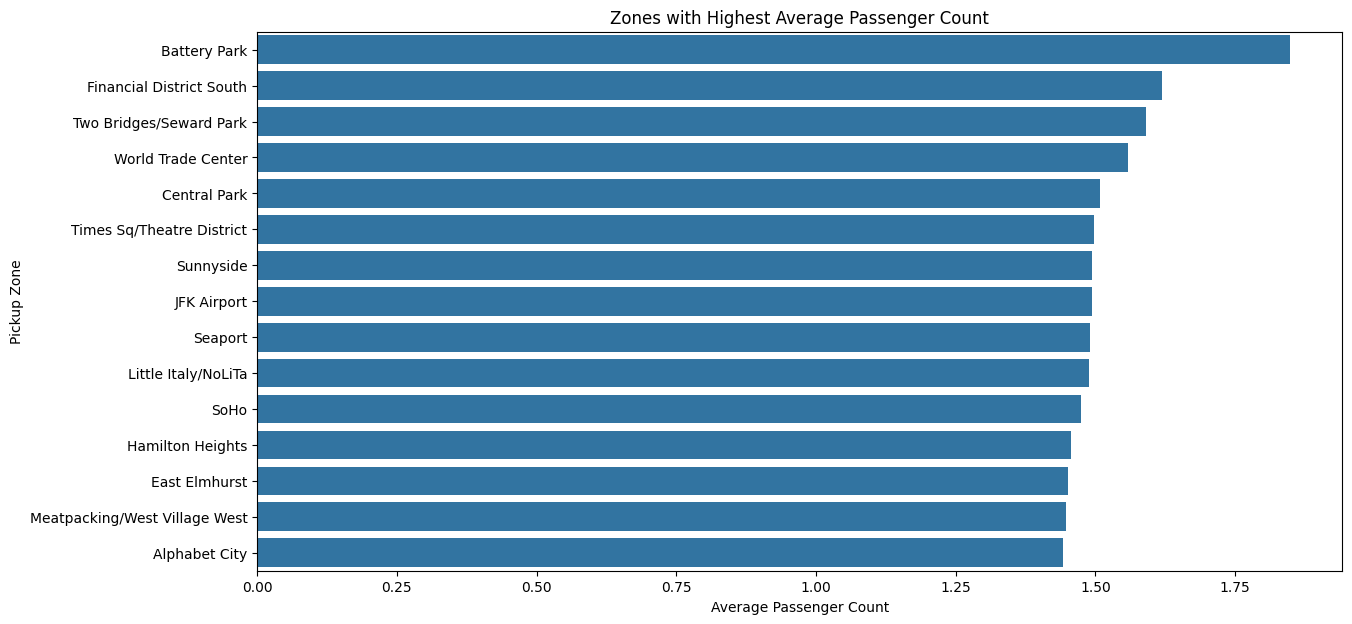

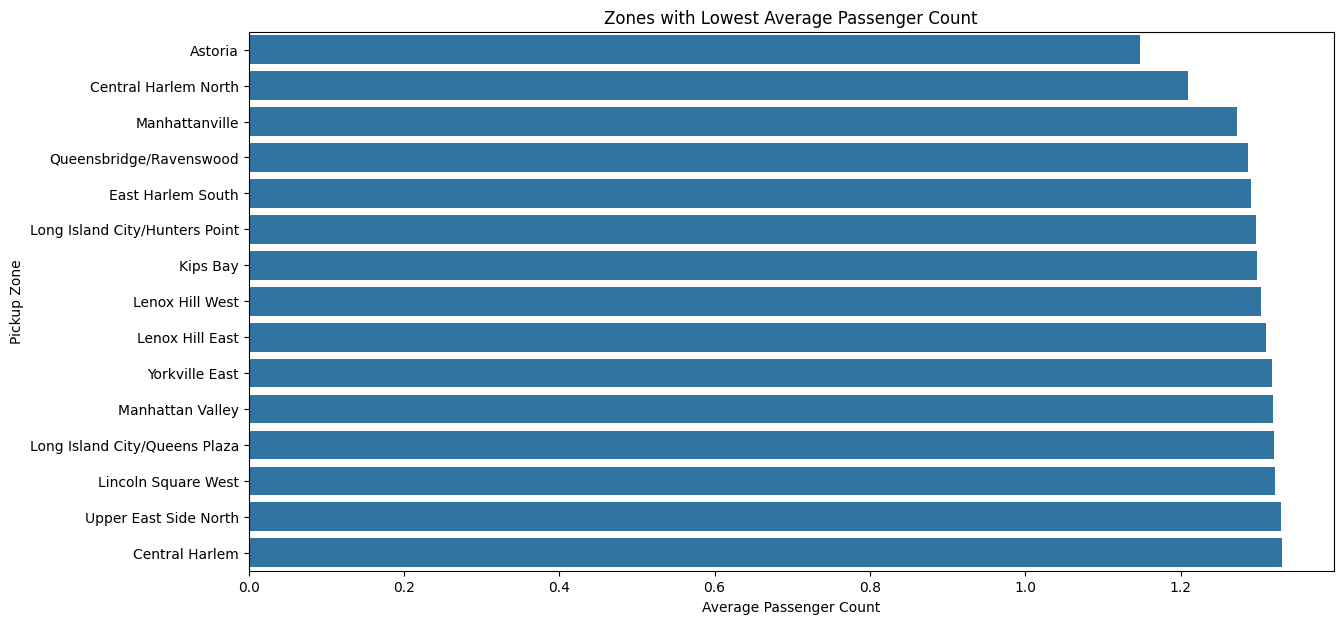

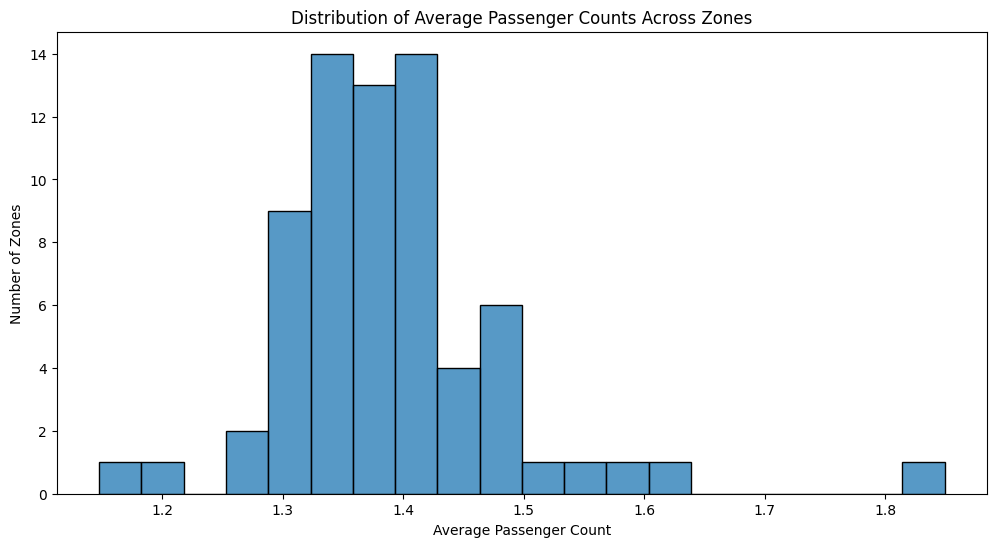

Highest Average Passenger Count Zone
pickup_zone        Battery Park
passenger_count        1.849206
trip_count                  126
Name: 8, dtype: object

Lowest Average Passenger Count Zone
pickup_zone         Astoria
passenger_count    1.147541
trip_count              122
Name: 4, dtype: object


In [72]:
# =========================================================
# 3.2.15 Passenger Count Variation Across Zones
# =========================================================
# How does passenger count vary across zones
# creating dataframe for zone passenger analysis

zone_passenger_df = pickup_zones_df.copy()

# removing invalid passenger counts

zone_passenger_df = zone_passenger_df[

    zone_passenger_df['passenger_count'] > 0
]

# calculating average passenger count by pickup zone

zone_passenger_analysis = (

    zone_passenger_df.groupby('pickup_zone')

    .agg({
        'passenger_count':'mean',
        'vendorid':'count'
    })

    .reset_index()
)

# renaming trip count column

zone_passenger_analysis.rename(

    columns={
        'vendorid':'trip_count'
    },

    inplace=True
)

# filtering zones with meaningful trip volume

zone_passenger_analysis = (

    zone_passenger_analysis[

        zone_passenger_analysis['trip_count'] >= 100
    ]
)

# sorting highest passenger zones

top_passenger_zones = (

    zone_passenger_analysis

    .sort_values(
        by='passenger_count',
        ascending=False
    )

    .head(15)
)

top_passenger_zones

# visualising top passenger zones

plt.figure(figsize=(14,7))

sns.barplot(

    data=top_passenger_zones,

    x='passenger_count',

    y='pickup_zone'
)

plt.title('Zones with Highest Average Passenger Count')

plt.xlabel('Average Passenger Count')

plt.ylabel('Pickup Zone')

plt.show()

# lowest passenger count zones

low_passenger_zones = (

    zone_passenger_analysis

    .sort_values(
        by='passenger_count',
        ascending=True
    )

    .head(15)
)

low_passenger_zones

# visualising low passenger zones

plt.figure(figsize=(14,7))

sns.barplot(

    data=low_passenger_zones,

    x='passenger_count',

    y='pickup_zone'
)

plt.title('Zones with Lowest Average Passenger Count')

plt.xlabel('Average Passenger Count')

plt.ylabel('Pickup Zone')

plt.show()

# distribution of passenger counts across all zones

plt.figure(figsize=(12,6))

sns.histplot(

    zone_passenger_analysis['passenger_count'],

    bins=20
)

plt.title('Distribution of Average Passenger Counts Across Zones')

plt.xlabel('Average Passenger Count')

plt.ylabel('Number of Zones')

plt.show()

# identifying peak passenger zone

highest_zone = top_passenger_zones.iloc[0]

lowest_zone = low_passenger_zones.iloc[0]

print('Highest Average Passenger Count Zone')
print(highest_zone)

print('\nLowest Average Passenger Count Zone')
print(lowest_zone)



In [75]:
# =========================================================
# Recreate zones_with_trips GeoDataFrame
# =========================================================

# grouping pickup counts by zone

trip_counts = (

    pickup_zones_df.groupby('pulocationid')

    .size()

    .reset_index(name='trip_count')
)

trip_counts.head()

# renaming pulocationid to LocationID

trip_counts.rename(

    columns={
        'pulocationid':'LocationID'
    },

    inplace=True
)

# merging trip counts into zones GeoDataFrame

zones_with_trips = zones.merge(

    trip_counts,

    on='LocationID',

    how='left'
)

# filling missing values

zones_with_trips['trip_count'] = (

    zones_with_trips['trip_count']

    .fillna(0)
)

# =========================================================
# Creating average passenger count column
# =========================================================

zone_avg_passenger = (

    pickup_zones_df.groupby('pulocationid')

    .agg({
        'passenger_count':'mean'
    })

    .reset_index()
)

# renaming columns

zone_avg_passenger.rename(

    columns={
        'pulocationid':'LocationID',
        'passenger_count':'avg_passenger_count'
    },

    inplace=True
)

# merging into zones_with_trips

zones_with_trips = zones_with_trips.merge(

    zone_avg_passenger,

    on='LocationID',

    how='left'
)

# filling missing values

zones_with_trips['avg_passenger_count'] = (

    zones_with_trips['avg_passenger_count']

    .fillna(0)
)

# preview

zones_with_trips[

    [
        'LocationID',
        'zone',
        'borough',
        'trip_count',
        'avg_passenger_count'
    ]

].head()



,LocationID,zone,borough,trip_count,avg_passenger_count
0,1,Newark Airport,EWR,28.0,1.785714
1,2,Jamaica Bay,Queens,0.0,0.000000
2,3,Allerton/Pelham Gardens,Bronx,4.0,1.000000
3,4,Alphabet City,Manhattan,269.0,1.442379
4,5,Arden Heights,Staten Island,2.0,1.000000


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

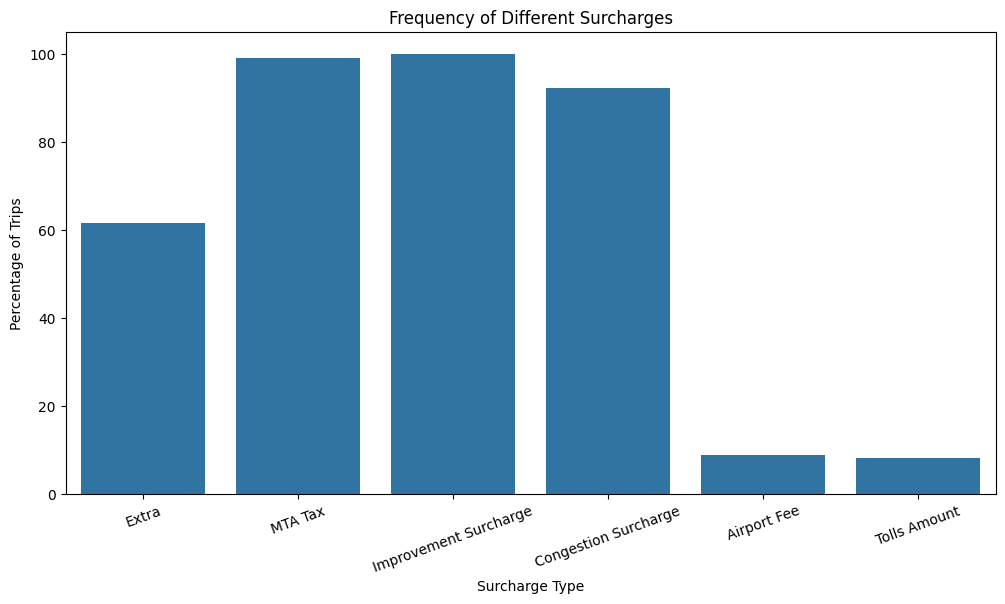

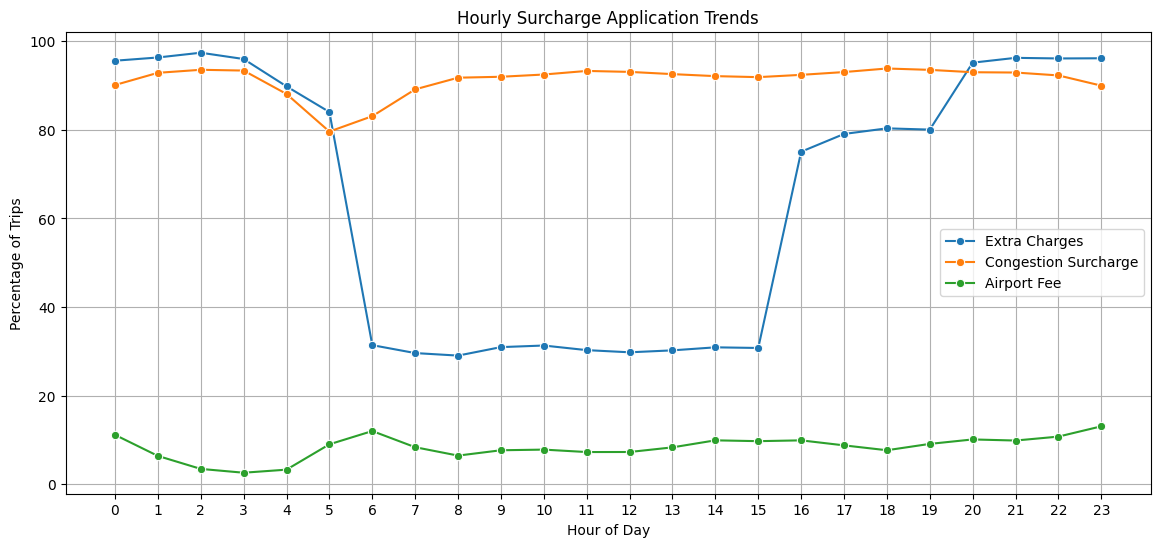

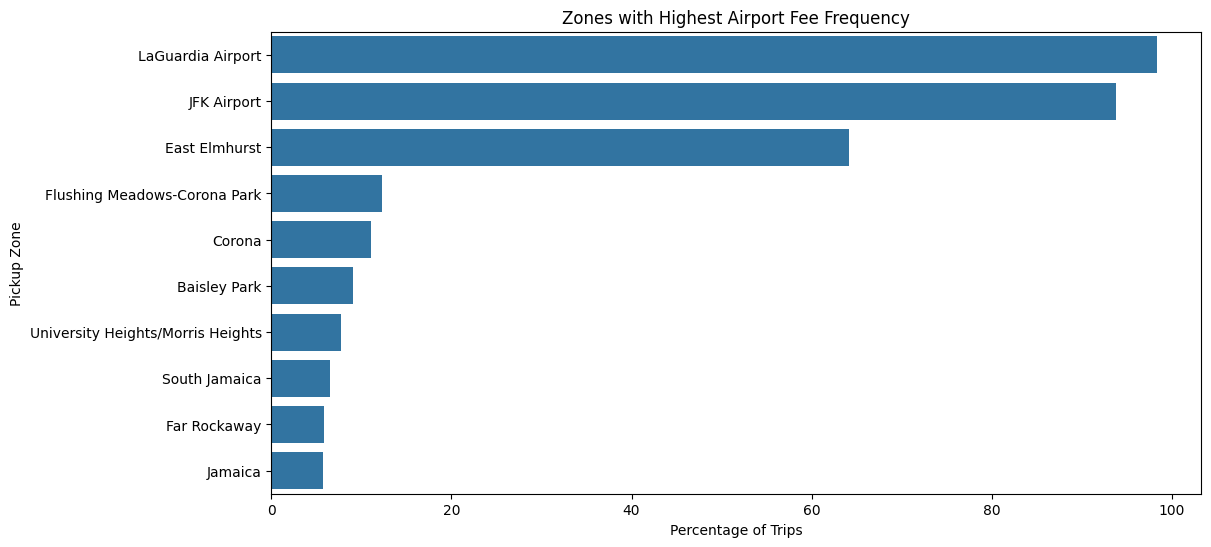

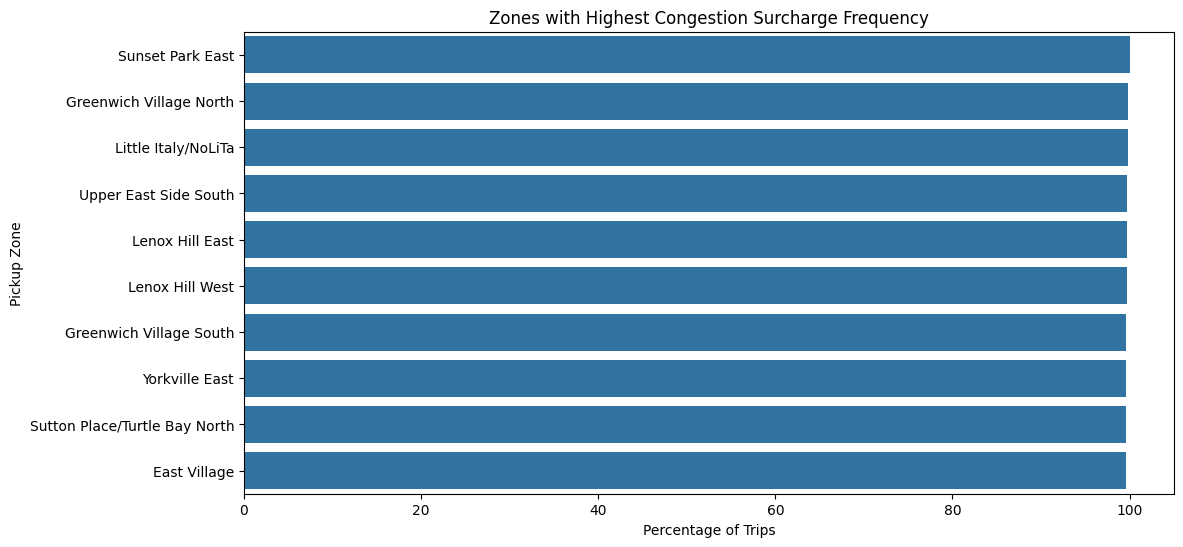

In [76]:
# =========================================================
# 3.2.16 Surcharge Analysis
# =========================================================
# How often is each surcharge applied?

# creating dataframe for surcharge analysis

surcharge_df = df.copy()

# Overall Surcharge Frequency
# checking how often surcharges are applied

surcharge_frequency = pd.DataFrame({

    'Surcharge_Type':[
        'Extra',
        'MTA Tax',
        'Improvement Surcharge',
        'Congestion Surcharge',
        'Airport Fee',
        'Tolls Amount'
    ],

    'Trips_With_Surcharge':[

        (surcharge_df['extra'] > 0).sum(),

        (surcharge_df['mta_tax'] > 0).sum(),

        (surcharge_df['improvement_surcharge'] > 0).sum(),

        (surcharge_df['congestion_surcharge'] > 0).sum(),

        (surcharge_df['airport_fee'] > 0).sum(),

        (surcharge_df['tolls_amount'] > 0).sum()
    ]
})

surcharge_frequency

# calculating percentage frequency

surcharge_frequency['Percentage'] = (

    surcharge_frequency['Trips_With_Surcharge']

    / surcharge_df.shape[0]

) * 100

surcharge_frequency

# plotting surcharge application frequency

plt.figure(figsize=(12,6))

sns.barplot(

    data=surcharge_frequency,

    x='Surcharge_Type',

    y='Percentage'
)

plt.title('Frequency of Different Surcharges')

plt.xlabel('Surcharge Type')

plt.ylabel('Percentage of Trips')

plt.xticks(rotation=20)

plt.show()

# Hourly Surcharge Trends

# calculating hourly surcharge frequency

hourly_surcharge = (

    surcharge_df.groupby('pickup_hour')

    .agg({

        'extra': lambda x: (x > 0).mean() * 100,

        'congestion_surcharge': lambda x: (x > 0).mean() * 100,

        'airport_fee': lambda x: (x > 0).mean() * 100
    })

    .reset_index()
)

hourly_surcharge.head()

# calculating hourly surcharge frequency

hourly_surcharge = (

    surcharge_df.groupby('pickup_hour')

    .agg({

        'extra': lambda x: (x > 0).mean() * 100,

        'congestion_surcharge': lambda x: (x > 0).mean() * 100,

        'airport_fee': lambda x: (x > 0).mean() * 100
    })

    .reset_index()
)

hourly_surcharge.head()

# plotting hourly surcharge patterns

plt.figure(figsize=(14,6))

sns.lineplot(

    data=hourly_surcharge,

    x='pickup_hour',

    y='extra',

    label='Extra Charges',

    marker='o'
)

sns.lineplot(

    data=hourly_surcharge,

    x='pickup_hour',

    y='congestion_surcharge',

    label='Congestion Surcharge',

    marker='o'
)

sns.lineplot(

    data=hourly_surcharge,

    x='pickup_hour',

    y='airport_fee',

    label='Airport Fee',

    marker='o'
)

plt.title('Hourly Surcharge Application Trends')

plt.xlabel('Hour of Day')

plt.ylabel('Percentage of Trips')

plt.xticks(range(0,24))

plt.grid(True)

plt.show()

# Pickup Zone Surcharge Analysis

# surcharge frequency by pickup zone

zone_surcharge_analysis = (

    pickup_zones_df.groupby('pickup_zone')

    .agg({

        'airport_fee': lambda x: (x > 0).mean() * 100,

        'congestion_surcharge': lambda x: (x > 0).mean() * 100,

        'extra': lambda x: (x > 0).mean() * 100
    })

    .reset_index()
)

zone_surcharge_analysis.head()

# top airport fee zones

top_airport_fee_zones = (

    zone_surcharge_analysis

    .sort_values(
        by='airport_fee',
        ascending=False
    )

    .head(10)
)

top_airport_fee_zones

# visualising airport fee zones

plt.figure(figsize=(12,6))

sns.barplot(

    data=top_airport_fee_zones,

    x='airport_fee',

    y='pickup_zone'
)

plt.title('Zones with Highest Airport Fee Frequency')

plt.xlabel('Percentage of Trips')

plt.ylabel('Pickup Zone')

plt.show()

# top congestion surcharge zones

top_congestion_zones = (

    zone_surcharge_analysis

    .sort_values(
        by='congestion_surcharge',
        ascending=False
    )

    .head(10)
)

top_congestion_zones

# visualising congestion surcharge zones

plt.figure(figsize=(12,6))

sns.barplot(

    data=top_congestion_zones,

    x='congestion_surcharge',

    y='pickup_zone'
)

plt.title('Zones with Highest Congestion Surcharge Frequency')

plt.xlabel('Percentage of Trips')

plt.ylabel('Pickup Zone')

plt.show()



## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

In [86]:
# =========================================================
# Peak pickup zones
# =========================================================

top_pickup_summary = (

    pickup_zones_df['pickup_zone']

    .value_counts()

    .head(10)
)

top_pickup_summary

# =========================================================
# Peak traffic hours
# =========================================================

peak_hour_summary = (

    df['pickup_hour']

    .value_counts()

    .sort_values(ascending=False)

    .head(10)
)

peak_hour_summary

# =========================================================
# Slowest traffic zones
# =========================================================

slowest_routes[

    [
        'pickup_zone',
        'time_period',
        'trip_speed_mph',
        'trip_count'
    ]

].head(10)

print("""
=========================================================
ROUTING AND DISPATCH OPTIMIZATION RECOMMENDATIONS
=========================================================

KEY OBSERVATIONS
---------------------------------------------------------
1. Manhattan dominates overall taxi activity,
   especially:
    • Midtown Center
    • Times Square
    • Upper East Side
    • Penn Station

2. Airport zones such as:
    • JFK Airport
    • LaGuardia Airport

   generate extremely high pickup demand.

3. Evening hours between:
    • 5 PM to 7 PM

   show maximum traffic demand.

4. Midtown regions show the slowest
   average travel speeds due to congestion.

=========================================================

RECOMMENDATIONS
---------------------------------------------------------

• Deploy higher taxi density in Midtown
  Manhattan during evening rush hours.

• Use predictive dispatching before
  evening demand spikes.

• Position dedicated airport fleets near:
    • JFK Airport
    • LaGuardia Airport

• Reduce idle roaming in congestion-heavy
  regions using smart routing algorithms.

• Use dynamic route balancing to minimize:
    • empty return trips
    • traffic bottlenecks
    • driver idle time

• Introduce congestion-aware routing
  during peak traffic windows.

=========================================================
""")


ROUTING AND DISPATCH OPTIMIZATION RECOMMENDATIONS

KEY OBSERVATIONS
---------------------------------------------------------
1. Manhattan dominates overall taxi activity,
   especially:
    • Midtown Center
    • Times Square
    • Upper East Side
    • Penn Station

2. Airport zones such as:
    • JFK Airport
    • LaGuardia Airport

   generate extremely high pickup demand.

3. Evening hours between:
    • 5 PM to 7 PM

   show maximum traffic demand.

4. Midtown regions show the slowest
   average travel speeds due to congestion.


RECOMMENDATIONS
---------------------------------------------------------

• Deploy higher taxi density in Midtown
  Manhattan during evening rush hours.

• Use predictive dispatching before
  evening demand spikes.

• Position dedicated airport fleets near:
    • JFK Airport
    • LaGuardia Airport

• Reduce idle roaming in congestion-heavy
  regions using smart routing algorithms.

• Use dynamic route balancing to minimize:
    • empty return trips
  

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

In [87]:
# =========================================================
# Night pickup hotspots
# =========================================================

night_pickup_zones.head(10)

# =========================================================
# Weekend peak demand hours
# =========================================================

weekend_peak_analysis = (

    hourly_daytype_trips[
        hourly_daytype_trips['day_type'] == 'Weekend'
    ]

    .sort_values(
        by='trip_count',
        ascending=False
    )

    .head(10)
)

weekend_peak_analysis

# =========================================================
# Monthly revenue trend
# =========================================================

monthly_revenue.head()

# =========================================================
# Passenger movement hotspots
# =========================================================

zones_sorted.head(10)

print("""
=========================================================
STRATEGIC CAB POSITIONING RECOMMENDATIONS
=========================================================

KEY OBSERVATIONS
---------------------------------------------------------

1. Manhattan and airport zones consistently
   generate the highest trip demand.

2. Nighttime demand is concentrated around:
    • East Village
    • Lower East Side
    • West Village
    • JFK Airport

3. Weekend demand patterns show stronger:
    • leisure travel
    • nightlife movement
    • group transportation

4. Revenue generation peaks during:
    • evening hours
    • airport activity
    • Midtown commercial traffic

=========================================================

RECOMMENDATIONS
---------------------------------------------------------

• Position higher fleet density in:
    • Midtown Manhattan
    • Times Square
    • JFK Airport
    • LaGuardia Airport

• Increase cab availability during:
    • 4 PM to 8 PM
    • weekend evenings
    • late-night airport windows

• Use demand forecasting to reposition
  idle taxis proactively.

• Deploy larger-capacity vehicles in:
    • tourism-heavy regions
    • nightlife districts
    • airport zones

• Avoid oversupplying low-demand zones
  in outer boroughs.

• Use dynamic zone-based positioning
  rather than static fleet allocation.

=========================================================
""")


STRATEGIC CAB POSITIONING RECOMMENDATIONS

KEY OBSERVATIONS
---------------------------------------------------------

1. Manhattan and airport zones consistently
   generate the highest trip demand.

2. Nighttime demand is concentrated around:
    • East Village
    • Lower East Side
    • West Village
    • JFK Airport

3. Weekend demand patterns show stronger:
    • leisure travel
    • nightlife movement
    • group transportation

4. Revenue generation peaks during:
    • evening hours
    • airport activity
    • Midtown commercial traffic


RECOMMENDATIONS
---------------------------------------------------------

• Position higher fleet density in:
    • Midtown Manhattan
    • Times Square
    • JFK Airport
    • LaGuardia Airport

• Increase cab availability during:
    • 4 PM to 8 PM
    • weekend evenings
    • late-night airport windows

• Use demand forecasting to reposition
  idle taxis proactively.

• Deploy larger-capacity vehicles in:
    • tourism-heavy regions
    

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

In [88]:
# =========================================================
# Fare per mile by hour
# =========================================================

hourly_fare_per_mile.head()

# =========================================================
# Vendor fare comparison
# =========================================================

vendor_summary

# =========================================================
# Distance tier pricing
# =========================================================

vendor_tier_pivot

# =========================================================
# Tip percentage insights
# =========================================================

distance_tip_analysis

print("""
=========================================================
DATA-DRIVEN PRICING STRATEGY RECOMMENDATIONS
=========================================================

KEY OBSERVATIONS
---------------------------------------------------------

1. Fare-per-mile is highest for:
    • short-distance trips
    • congested urban travel

2. Vendor 2 consistently shows higher
   fare-per-mile values.

3. Evening hours show:
    • stronger pricing efficiency
    • higher congestion impact

4. Short-distance trips generate:
    • stronger revenue efficiency
    • higher tip percentages

5. Long-distance trips show:
    • lower fare-per-mile
    • but higher total fare value

=========================================================

RECOMMENDATIONS
---------------------------------------------------------

• Introduce dynamic pricing during:
    • evening rush hours
    • airport demand peaks
    • congestion-heavy periods

• Maintain competitive pricing for
  short-distance urban trips.

• Use airport-specific pricing models
  for predictable customer experience.

• Encourage pooled/shared rides to:
    • improve occupancy
    • reduce congestion
    • improve revenue efficiency

• Apply zone-aware pricing in:
    • Midtown Manhattan
    • airport corridors
    • entertainment districts

• Improve fare transparency around:
    • congestion charges
    • airport fees
    • tolls
    • dynamic pricing adjustments

=========================================================
""")


DATA-DRIVEN PRICING STRATEGY RECOMMENDATIONS

KEY OBSERVATIONS
---------------------------------------------------------

1. Fare-per-mile is highest for:
    • short-distance trips
    • congested urban travel

2. Vendor 2 consistently shows higher
   fare-per-mile values.

3. Evening hours show:
    • stronger pricing efficiency
    • higher congestion impact

4. Short-distance trips generate:
    • stronger revenue efficiency
    • higher tip percentages

5. Long-distance trips show:
    • lower fare-per-mile
    • but higher total fare value


RECOMMENDATIONS
---------------------------------------------------------

• Introduce dynamic pricing during:
    • evening rush hours
    • airport demand peaks
    • congestion-heavy periods

• Maintain competitive pricing for
  short-distance urban trips.

• Use airport-specific pricing models
  for predictable customer experience.

• Encourage pooled/shared rides to:
    • improve occupancy
    • reduce congestion
    • improve revenue 